
# House price prediction, part 1

## Completed as part of the coursework for the Data Mining and Knowledge Discovery in Data module at the University of Brighton, 2025/26.

In [ ]:
#| label: import-libraries
#| eval: true
#| echo: false
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy.stats import norm
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tabulate import tabulate

```{}
```



# Introduction

## Background

House prices depend on many factors, including location, size, age, condition, and market dynamics, which makes valuation challenging. Yet obtaining reliable price estimates is needed to enable buyers, sellers, lenders, and policymakers to make informed decisions. Traditional predictions rely on human judgment and can be inconsistent. Machine learning provides a more systematic and scalable approach, learning complex relationships between property features and price from large datasets [@li2024; @simanungkalit2023].

## Data analysis objective

This report presents exploratory data analysis and pre-processing of the King County house sales dataset, which contains property features and sale prices. The analysis covers data understanding, exploration, and pre-processing, aiming to prepare the data for machine learning regression models to predict house prices [@wu2024]. When pre-processing is outside this report's scope, recommendations are given instead of implementation, to show a complete analytical pipeline rather than a production-ready dataset.

# Method and Outline

All analyses were conducted in Python, following standard methodology for data manipulation and visualisation [@building2024; @datapre2025; @eda-ex2026a; @housepr2026]. Full code is provided in @sec-appendix.

@sec-du describes the dataset, variable types, descriptive statistics, and data quality; @sec-du-ana examines distributions and relationships; and @sec-pp outlines the pre‑processing steps.

# Data Understanding {#sec-du}

## Dataset inspection {#sec-du-overview}

The dataset includes 21,614 house sale records and 21 attributes, with an overview in @tbl-records, and the first 5 records shown in @tbl-data-header.

| Description                   | Value                |
|-------------------------------|----------------------|
| Location                      | Kings County, USA    |
| Time period                   | May 2014 to May 2015 |
| Number of records (rows)      | 21614                |
| Number of variables (columns) | 21                   |
| Target variable               | house price          |

: Dataset overview {#tbl-records}

In [ ]:
#| label: import-dataset
#data = pd.read_csv("/data/Houses_price_dataset.csv")
data = pd.read_csv("../data/Houses_price_dataset.csv")


In [ ]:
#| label: data-shape
#| echo: false
data.shape

(21614, 21)

In [ ]:
#| label: tbl-data-header
#| tbl-cap: "Dataset preview (first 5 rows)"

print(data.head(5))

           id             date   price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900         3       1.00         1180   
1  6414100192  20141209T000000  538000         3       2.25         2570   
2  5631500400  20150225T000000  180000         2       1.00          770   
3  2487200875  20141209T000000  604000         4       3.00         1960   
4  1954400510  20150218T000000  510000         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     long  sqft_liv

## Variables and data types {#sec-du-vars}

Each variable was inspected for correct data types, description, and values. Seven variables required type reassignment, as summarised in @tbl-data-types-before-after. No variables were dropped or created at this stage.

The dataset included both numerical and categorical variables. Numerical fields comprised discrete (counts) and continuous (measures), mostly stored as `int64`. A few were `float64` for practical reasons. For example, 'bathrooms' and 'floors' used fractional values following U.S. real‑estate conventions—such as 1.5 bathrooms to denote one full bathroom (4 fixtures) plus one half bath (two fixtures) [@wilson2017], or 1.5 floors to indicate a partial upper level [@therisi2021]. 'Lat' and 'long' were stored as floats, as they represent continuous decimal coordinates. The 2025 square‑footage value appeared as a float rather than an integer, unlike similar entries, but this inconsistency did not affect the analysis.

In [ ]:
#| label: data-types-before
# Capture original datatypes after importing the dataset
before = data.dtypes.reset_index()
before.columns = ["Variable", "Imported dtype"]

In [ ]:
#| label: comments
# Make comments for the original datatypes
comments = {
    "id": "house identifierr",
    "date": "sales date",
    "price": "house sales price ",
    "bedrooms": "number of bedrooms ",
    "bathrooms": "number of bathrooms",
    "sqft_living": "square footage house",
    "sqft_lot": "square footage lot ",
    "floors": "number of floors",
    "waterfront": "includes waterfront",
    "view": "quality of the view",
    "condition": "condition of the house",
    "grade": "grade of the house",
    "sqft_above": "sqft excl. basement",
    "sqft_basement": "sqft basement",
    "yr_built": "year house built",
    "yr_renovated": "year house renovated",
    "zipcode": "zip code",
    "lat": "latitude",
    "long": "longitute",
    "sqft_living15": "sqft house, 2015",
    "sqft_lot15": "sqft lot, 2015"
}

In [ ]:
#| label: notes
# Make notes on validation decis
notes = {
    "id": "unord. categorical",
    "date": "datetime",
    "price": "no change ",
    "bedrooms": "no change",
    "bathrooms": "no change",
    "sqft_living": "no change",
    "sqft_lot": "no change",
    "floors": "no change",
    "waterfront": "bool (True/False)",
    "view": "ord. categorical (0–4)",
    "condition": "ord. categorical (1–5)",
    "grade": "ord. categorical (1–13)",
    "sqft_above": "no change",
    "sqft_basement": "no change",
    "yr_built": "no change",
    "yr_renovated": "no change",
    "zipcode": "unord. categorical",
    "lat": "no change",
    "long": "no change",
    "sqft_living15": "no change",
    "sqft_lot15": "no change"
}

In [ ]:
#| label: data-types-change
# Seven changes made to imported data types
data["id"] = data["id"].astype("category")
data["date"] = data["date"].astype("datetime64[ns]")
data["waterfront"] = data["waterfront"].astype("bool")
data["view"] = data["view"].astype("category")
data["condition"] = data["condition"].astype("category")
data["grade"] = data["grade"].astype("category")
data["zipcode"] = data["zipcode"].astype("category")

In [ ]:
#| label: categorical-ordered
data["view"] = data["view"].cat.as_ordered()
data["condition"] = data["condition"].cat.as_ordered()
data["grade"] = data["grade"].cat.as_ordered()

In [ ]:
#| label: data-types-after
# Capture validated datatypes after changes made
after = data.dtypes.reset_index()
after.columns = ["Variable", "Validated dtype"]

In [ ]:
#| label: tbl-data-types-before-after
#| tbl-cap: "Variables data type validation"
#| output: asis

dtype_table = before.merge(after, on="Variable")
dtype_table["Comments"] = dtype_table["Variable"].map(comments)
dtype_table["Validation"] = dtype_table["Variable"].map(notes)
dtype_table = dtype_table[["Variable", "Imported dtype", "Validated dtype", "Comments", "Validation"]]

print(tabulate(dtype_table, headers='keys', tablefmt='latex_booktabs', showindex=False))

\begin{tabular}{lllll}
\toprule
 Variable      & Imported dtype   & Validated dtype   & Comments               & Validation              \\
\midrule
 id            & int64            & category          & house identifierr      & unord. categorical      \\
 date          & str              & datetime64[ns]    & sales date             & datetime                \\
 price         & int64            & int64             & house sales price      & no change               \\
 bedrooms      & int64            & int64             & number of bedrooms     & no change               \\
 bathrooms     & float64          & float64           & number of bathrooms    & no change               \\
 sqft\_living   & int64            & int64             & square footage house   & no change               \\
 sqft\_lot      & int64            & int64             & square footage lot     & no change               \\
 floors        & float64          & float64           & number of floors       & no change   

## Missing and duplicate data

**Missing data**

Missing values were found in the 'sqft_living15' and 'sqft_lot15'. Each had 21,612 entries compared to 21,614 for all other variables (see @tbl-data-info).

In [ ]:
#| label: tbl-data-info
#| tbl-cap: Non-null value counts for each variable
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 21614 entries, 0 to 21613
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21614 non-null  category      
 1   date           21614 non-null  datetime64[ns]
 2   price          21614 non-null  int64         
 3   bedrooms       21614 non-null  int64         
 4   bathrooms      21614 non-null  float64       
 5   sqft_living    21614 non-null  int64         
 6   sqft_lot       21614 non-null  int64         
 7   floors         21614 non-null  float64       
 8   waterfront     21614 non-null  bool          
 9   view           21614 non-null  category      
 10  condition      21614 non-null  category      
 11  grade          21614 non-null  category      
 12  sqft_above     21614 non-null  int64         
 13  sqft_basement  21614 non-null  int64         
 14  yr_built       21614 non-null  int64         
 15  yr_renovated   21614 non-null 

**Duplicate data**

There were 21,437 unique 'id' values for 21,614 transactions (@tbl-data-unique-trans), indicating some houses were sold more than once. Among the 353 duplicate 'id' records (@tbl-data-duplicate-id), 175 houses were sold twice, and one three times. For these repeat sales, as the property features remained unchanged—except for the date and price— each transaction was treated as an independent record.

In [ ]:
#| label: tbl-data-unique-trans
#| tbl-cap: Unique value counts for each variable
data.nunique()

id               21437
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8688
dtype: int64

In [ ]:
#| label: tbl-data-duplicate-id
#| tbl-cap: Duplicate id records

# Find ids that appear more than once
duplicate_ids = data[data.duplicated(subset="id", keep=False)]

# Sort by id
duplicate_ids = duplicate_ids.sort_values("id")

# Show relevant columns
cols = ["id", "date", "price", "bedrooms", "grade", "sqft_living"]
print(duplicate_ids[cols])

# Summary count
print(f"\nNumber of duplicate id records: {len(duplicate_ids)}")
print(f"Number of houses sold more than once: {duplicate_ids['id'].nunique()}")

               id       date   price  bedrooms grade  sqft_living
2497      1000102 2015-04-22  300000         6     7         2400
2496      1000102 2014-09-16  280000         6     7         2400
16814     7200179 2014-10-16  150000         2     6          840
16815     7200179 2015-04-24  175000         2     6          840
11434   109200390 2014-10-20  250000         3     7         1480
...           ...        ...     ...       ...   ...          ...
6345   9828200460 2014-06-27  260000         2     7          700
15200  9834200305 2015-02-10  615000         3     7         1790
15199  9834200305 2014-07-16  350000         3     7         1790
1085   9834200885 2014-07-17  360000         4     7         2080
1086   9834200885 2015-04-20  550000         4     7         2080

[353 rows x 6 columns]

Number of duplicate id records: 353
Number of houses sold more than once: 176


## Descriptive statistics {#sec-du-stats}

Descriptive statistics were calculated for the target and numerical features, excluding date, categorical, logical, and coordinate variables. Results are presented in @tbl-statistics-raw.

'Price' is likely right-skewed, with a mean (\$540,075) above the median (\$450,000), and a maximum of \$7.7m indicating high-end outliers.

In [ ]:
#| label: data_subset
data_subset = data[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']].copy()

In [ ]:
#| label: tbl-statistics-raw
#| tbl-cap: "Descriptive statistics"
#| output: asis
desc_T = data_subset.describe().T.round(2)

print(tabulate(desc_T, headers='keys', tablefmt='latex_booktabs', showindex=True))

\begin{tabular}{lrrrrrrrr}
\toprule
               &   count &      mean &       std &   min &       25\% &       50\% &      75\% &              max \\
\midrule
 price         &   21614 & 540075    & 367124    & 75000 & 321612    & 450000    & 645000   &      7.7e+06     \\
 bedrooms      &   21614 &      3.37 &      0.93 &     0 &      3    &      3    &      4   &     33           \\
 bathrooms     &   21614 &      2.11 &      0.77 &     0 &      1.75 &      2.25 &      2.5 &      8           \\
 sqft\_living   &   21614 &   2079.85 &    918.45 &   290 &   1425.5  &   1910    &   2550   &  13540           \\
 sqft\_lot      &   21614 &  15106.3  &  41419.7  &   520 &   5040    &   7617.5  &  10687.8 &      1.65136e+06 \\
 floors        &   21614 &      1.49 &      0.54 &     1 &      1    &      1.5  &      2   &      3.5         \\
 sqft\_above    &   21614 &   1788.36 &    828.09 &   290 &   1190    &   1560    &   2210   &   9410           \\
 sqft\_basement &   21614 &    291.5 

# Exploratory Data Analysis {#sec-du-ana}

Numerical features (@tbl-num-features) were grouped into count, area, temporal, and geographical categories, used throughout the analysis.

In [ ]:
#| label: subset-features-num
# Create subset with numerical features - counts, area, temp, geo
col_num_counts = ['bedrooms', 'bathrooms', 'floors']
col_num_area = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']
col_num_temp = ['yr_built', 'yr_renovated']
col_num_geo = ['lat', 'long']

In [ ]:
#| label: tbl-num-features
#| tbl-cap: "Summary of numerical features"
#| output: asis
# Create subset with numerical features only
data_num_features = data[['bedrooms', 'bathrooms', 'floors', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'yr_built', 'yr_renovated', 'lat', 'long']].copy()
# Create table showing dtype, counts and missing
data_num_info = pd.DataFrame({
    'Variable': data_num_features.dtypes.index,
    'Non-Null Count': data_num_features.notnull().sum().values,
    'Missing': data_num_features.isnull().sum().values,
    'Dtype': data_num_features.dtypes.values
})
# print
print(data_num_info.to_markdown(index=False))

| Variable      |   Non-Null Count |   Missing | Dtype   |
|:--------------|-----------------:|----------:|:--------|
| bedrooms      |            21614 |         0 | int64   |
| bathrooms     |            21614 |         0 | float64 |
| floors        |            21614 |         0 | float64 |
| sqft_living   |            21614 |         0 | int64   |
| sqft_lot      |            21614 |         0 | int64   |
| sqft_above    |            21614 |         0 | int64   |
| sqft_basement |            21614 |         0 | int64   |
| sqft_living15 |            21612 |         2 | float64 |
| sqft_lot15    |            21612 |         2 | float64 |
| yr_built      |            21614 |         0 | int64   |
| yr_renovated  |            21614 |         0 | int64   |
| lat           |            21614 |         0 | float64 |
| long          |            21614 |         0 | float64 |


In [ ]:
#| label: subset-features-print
print("Count variables:")
for col in col_num_counts:
    print(f"  - {col}")

print("\nArea variables:")
for col in col_num_area:
    print(f"  - {col}")

print("\nTemporal variables:")
for col in col_num_temp:
    print(f"  - {col}")

print("\nGeographical variables:")
for col in col_num_geo:
    print(f"  - {col}")

Count variables:
  - bedrooms
  - bathrooms
  - floors

Area variables:
  - sqft_living
  - sqft_lot
  - sqft_above
  - sqft_basement
  - sqft_living15
  - sqft_lot15

Temporal variables:
  - yr_built
  - yr_renovated

Geographical variables:
  - lat
  - long


Categorical features include one logical and three ordinal variables (@tbl-cat-features).

In [ ]:
#| label: tbl-cat-features
#| tbl-cap: "Summary of categorical features"
#| output: asis
# Create subset with numerical features only
data_cat_features = data[['waterfront', 'view', 'condition', 'grade']].copy()
# Create table showing dtype, counts and missing
data_cat_info = pd.DataFrame({
    'Variable': data_cat_features.dtypes.index,
    'Non-Null Count': data_cat_features.notnull().sum().values,
    'Missing': data_cat_features.isnull().sum().values,
    'Dtype': data_cat_features.dtypes.values
})
# print
print(data_cat_info.to_markdown(index=False))

| Variable   |   Non-Null Count |   Missing | Dtype    |
|:-----------|-----------------:|----------:|:---------|
| waterfront |            21614 |         0 | bool     |
| view       |            21614 |         0 | category |
| condition  |            21614 |         0 | category |
| grade      |            21614 |         0 | category |


In [ ]:
#| label: subset-features-cat
# Specify columns for categorical features
col_cat = ['waterfront', 'view', 'condition', 'grade']

Three variables were excluded from exploration. 'Id' has no predictive value and 'zipcode' and 'date' due to their high cardinality - 70 and 372 unique values respectively - making meaningful exploration impractical without further transformation.

## Target variable {#sec-du-target}

The histogram (@fig-target-hist) shows that the distribution of 'price' is unimodal and strongly right-skewed (skewness 4.02, kurtosis 34.59), with most houses priced approximately \$300,000–\$500,000. This indicates that while most properties fall within an affordable price range, a small number of expensive properties create a pronounced heavy tail in the dataset. The box plot (@fig-target-box) confirms this with a compact interquartile range below \$1m and outliers up to \$7.5m.

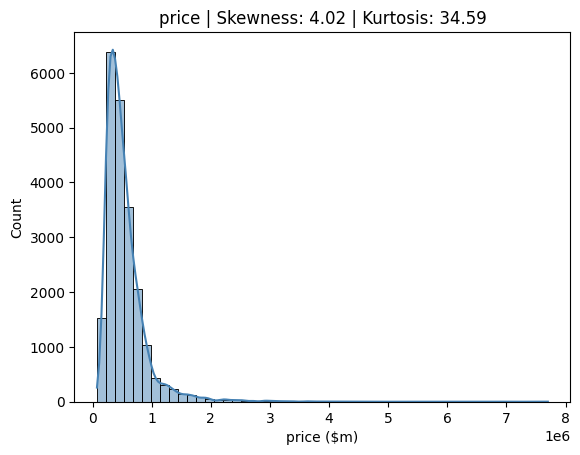

In [ ]:
#| label: fig-target-hist
#| fig-cap: "Histogram of house price distribution"
sns.histplot(data['price'], bins=50, color='steelblue', edgecolor='black', kde=True)
plt.title(f"price | Skewness: {round(data['price'].skew(), 2)} | Kurtosis: {round(data['price'].kurt(), 2)}")
plt.xlabel('price ($m)')
plt.show()

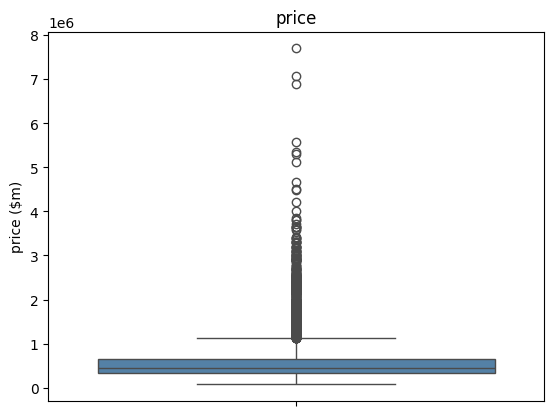

In [ ]:
#| label: fig-target-box
#| fig-cap: "Box plot of house price distribution"
sns.boxplot(data['price'], color='steelblue')
plt.title("price")
plt.ylabel('price ($m)')
plt.show()

## Univariate analysis {#sec-du-num-uni}

This section explores the distribution of each numerical and categorical feature.

**Count features**

As per @fig-uni-num-counts, most houses have 3-4 bedrooms, 2.5 bathrooms and are single- or double-story homes.

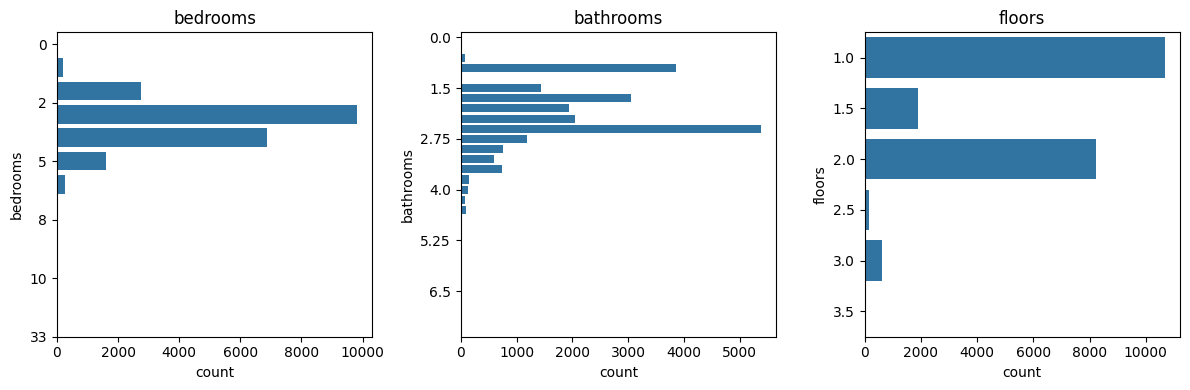

In [ ]:
#| label: fig-uni-num-counts
#| fig-cap: "Count plots of discrete numeric features"

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, var in enumerate(col_num_counts):
    sns.countplot(data=data, y=var, ax=axes[i])
    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=6))  # limit to 6 ticks
    axes[i].set_title(var)
plt.tight_layout()
plt.show()

**Area features**

As shown in @fig-uni-num-area, 'sqft_living', 'sqft_above', and 'sqft_living15' are right-skewed, peaking at 1,000–2,000 sqft with long upper tails. 'Sqft_lot' and 'sqft_lot15' are concentrated near zero with extreme right tails, likely large rural or undeveloped plots. Most properties have no basement.

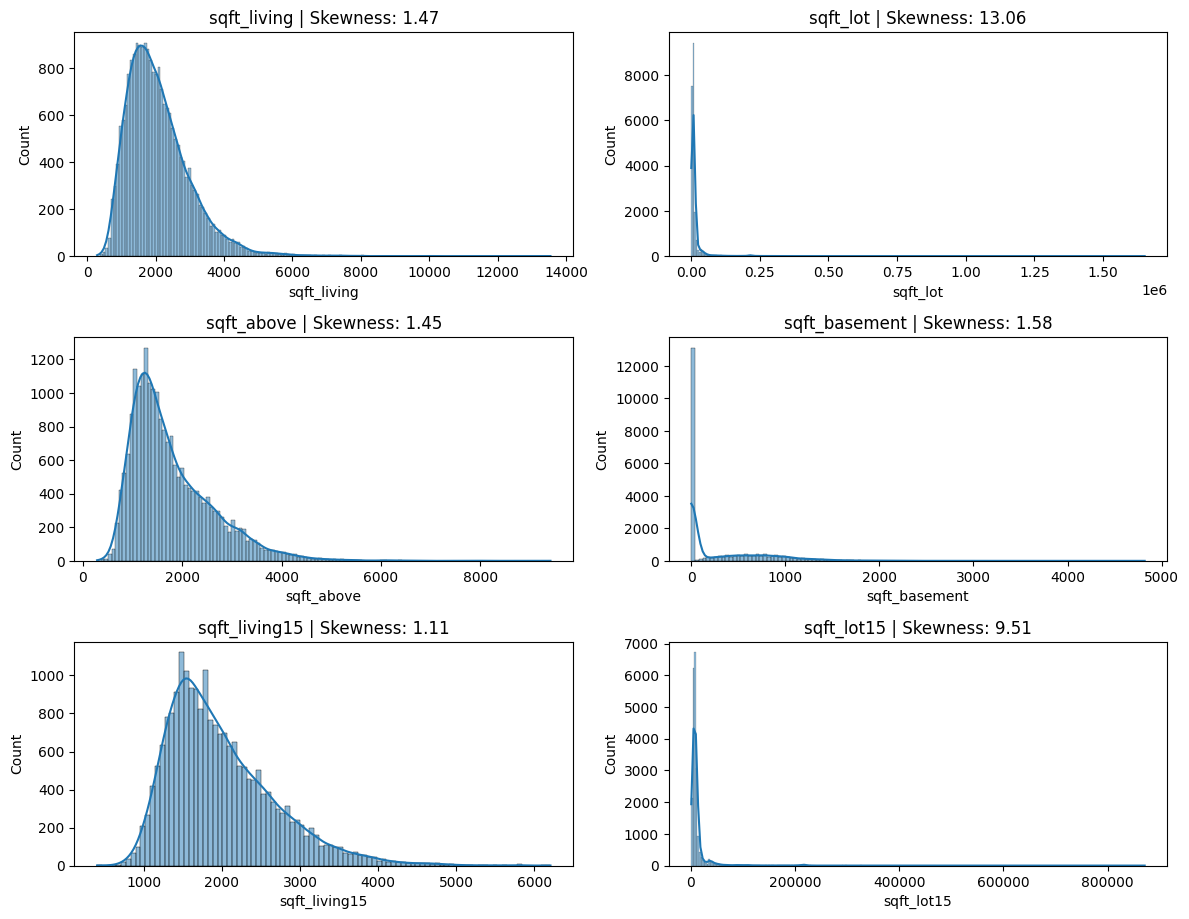

In [ ]:
#| label: fig-uni-num-area
#| fig-cap: "Histogram of area numeric features"

plt.figure(figsize=(12, len(col_num_area) * 3))
for i, var in enumerate(col_num_area, 1):
    plt.subplot(len(col_num_area), 2, i)
    sns.histplot(data[var], kde=True)
    plt.title(f"{var} | Skewness: {round(data[var].skew(), 2)}")

plt.tight_layout()
plt.show()

**Temporal features**

'Yr_built' ranges from 1900 to 2015 (@fig-uni-num-temp-hist), with construction peaking around 2000–2010. Most properties (95.8%) have never been renovated (@fig-uni-num-temp-pie). Although renovations are rare in the dataset, their frequency increased noticeably from the 1970s through 2010s (@fig-uni-num-temp-hist).

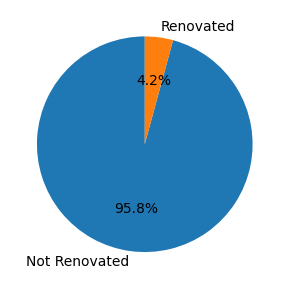

In [ ]:
#| label: fig-uni-num-temp-pie
#| fig-cap: "Pie chart of renovated vs. non-renovated houses"
renovated_counts = data["yr_renovated"].apply(lambda x: "Renovated" if x != 0 else "Not Renovated").value_counts()

fig, ax = plt.subplots(figsize=(3, 3))
ax.pie(renovated_counts, labels=renovated_counts.index, autopct="%1.1f%%", startangle=90)

plt.tight_layout()
plt.show()

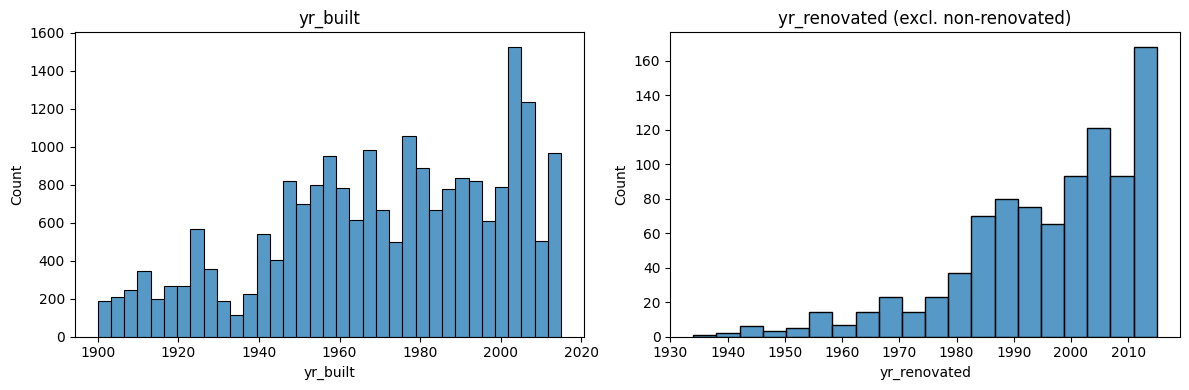

In [ ]:
#| label: fig-uni-num-temp-hist
#| fig-cap: "Histogram of temporal numeric features"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(col_num_temp):
    plot_data = data[data[var] != 0][var] if var == "yr_renovated" else data[var]
    sns.histplot(plot_data, ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var if var != "yr_renovated" else "yr_renovated (excl. non-renovated)")

plt.tight_layout()
plt.show()

**Geographic features**

Both coordinates, 'lat' and 'long', are multimodal (@fig-uni-num-geo), possibly indicating distinct neighbourhoods across the King County area.

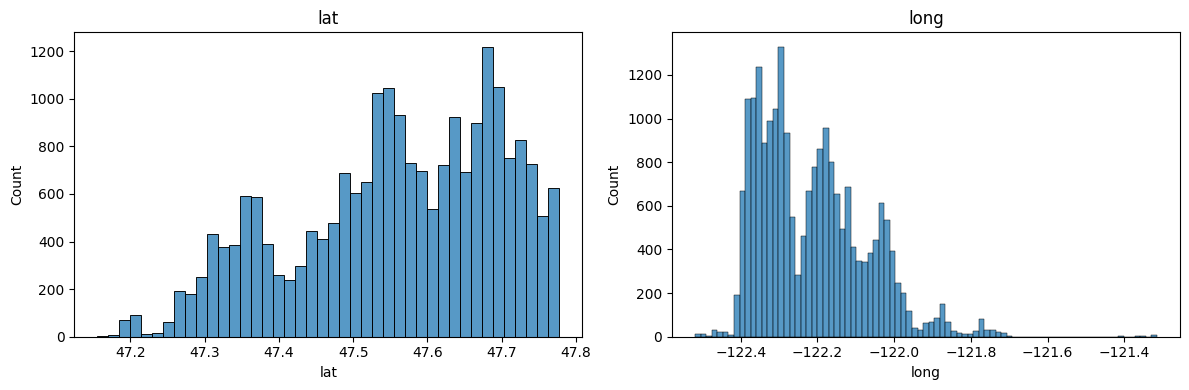

In [ ]:
#| label: fig-uni-num-geo
#| fig-cap: "Histogram of geographic numeric features"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(col_num_geo):
    sns.histplot(data[var], ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

**Categorical features**

As shown in @fig-uni-cat-hist, most houses have a 'view' rating of 0, meaning no scenic view. 'Condition' centres at 3 (average/good), while 'grade' is roughly normal, around 7-8. Only 0.8% of properties have 'waterfront' (@fig-uni-cat-pie).

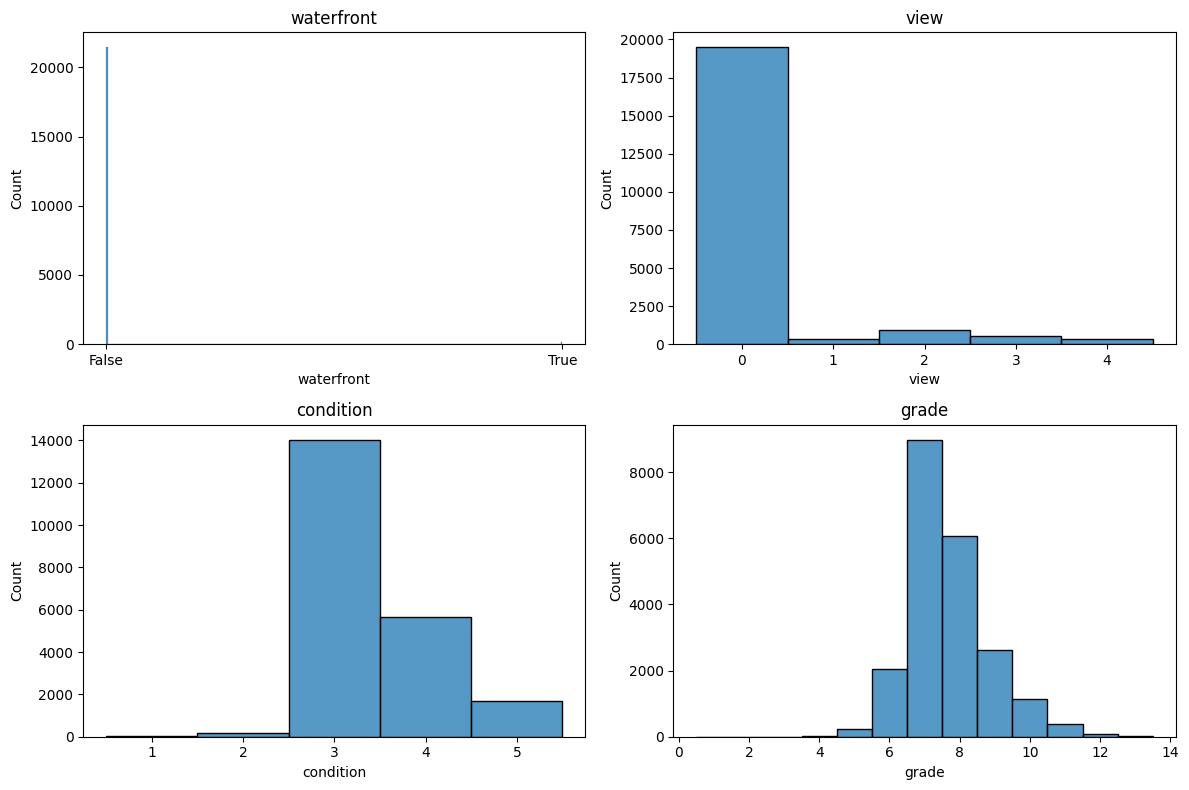

In [ ]:
#| label: fig-uni-cat-hist
#| fig-cap: "Histograms of categorical features"
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, var in enumerate(col_cat):
    sns.histplot(data[var], ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var)
    if data[var].dtype == bool:
        axes.flatten()[i].set_xticks([0, 1])
        axes.flatten()[i].set_xticklabels(["False", "True"])

plt.tight_layout()
plt.show()

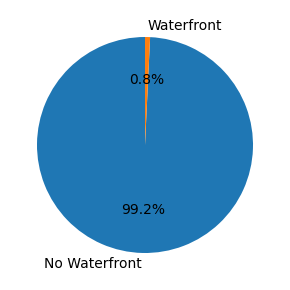

In [ ]:
#| label: fig-uni-cat-pie
#| fig-cap: "Pie chart of waterfront vs. no waterfront houses"

waterfront_counts = data["waterfront"].apply(lambda x: "Waterfront" if x != 0 else "No Waterfront").value_counts()

fig, ax = plt.subplots(figsize=(3, 3))
ax.pie(waterfront_counts, labels=waterfront_counts.index, autopct="%1.1f%%", startangle=90)

plt.tight_layout()
plt.show()

## Bivariate analysis {#sec-du-num-bi}

This section explores how each feature relates to 'price'.

**Count Variable vs. Price**

As per @fig-bi-num-count, 'bathroom' has the strongest positive association with price. 'Bedroom' show a weaker pattern, peaking at 5-6 bedrooms before declining. There is one outlier with 33 bedrooms. 'Floor' have little impact but two-storey homes tend to have higher prices.

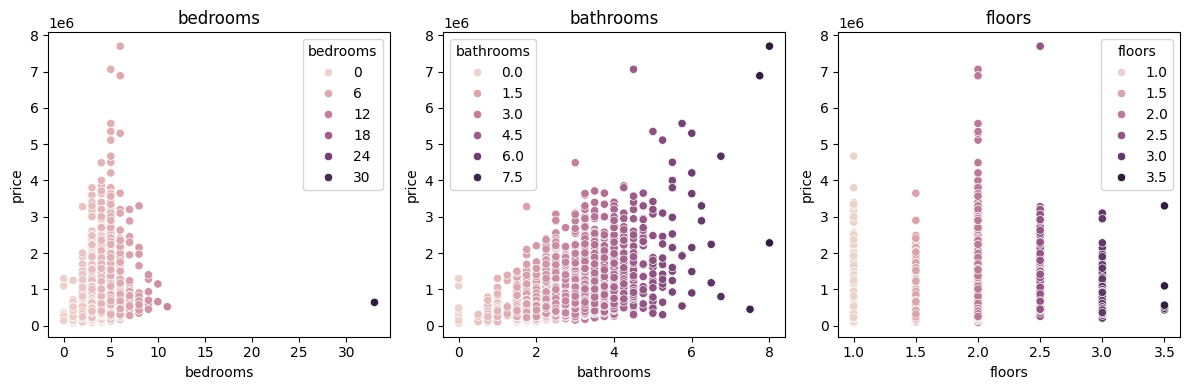

In [ ]:
#| label: fig-bi-num-count
#| fig-cap: "Scatter plot of discrete numeric features and house price"
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, var in enumerate(col_num_counts):
    sns.scatterplot(data=data, x=var, y='price', hue = var, ax=axes[i])
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

**Area Variable vs. Price**

Shown in @fig-bi-num-area, 'sqft_living', 'sqft_above', and 'sqft_living15' all show a positive relationship with price, with 'sqft_living' strongest. 'Sqft_basement' has a weak trend; 'sqft_lot' and 's'qft_lot15' show no clear link.

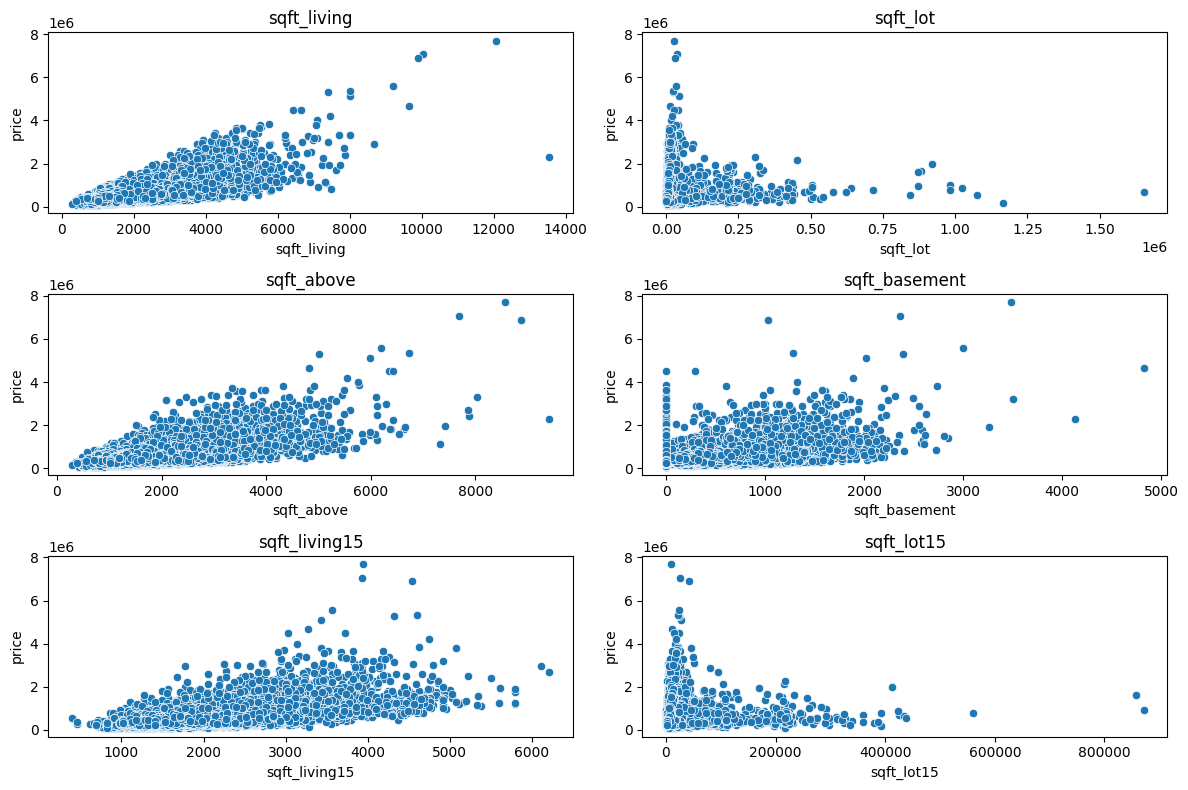

In [ ]:
#| label: fig-bi-num-area
#| fig-cap: "Scatter plot of area numeric features and house price"
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for i, var in enumerate(col_num_area):
    sns.scatterplot(data=data, x=var, y='price', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

**Temporal Variable vs. Price**

Neither 'yr_built' nor 'yr_renovated' shows a clear link to price; prices appear consistent across all years (@fig-bi-num-temp). A few high-value outliers appear.

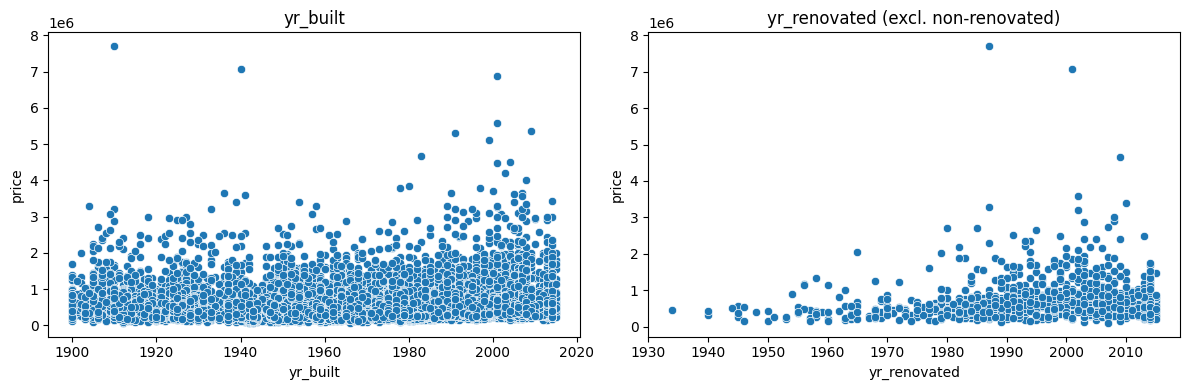

In [ ]:
#| label: fig-bi-num-temp
#| fig-cap: "Scatter plot of temporal numeric features and house price"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(col_num_temp):
    plot_data = data[data[var] != 0] if var == "yr_renovated" else data
    sns.scatterplot(data=plot_data, x=var, y='price', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var if var != "yr_renovated" else "yr_renovated (excl. non-renovated)")

plt.tight_layout()
plt.show()

**Geographic Variable vs. Price**

Plot shows higher prices cluster around lat 47.5–47.6, long −122.2 with lower prices are on the periphery (@fig-coord).

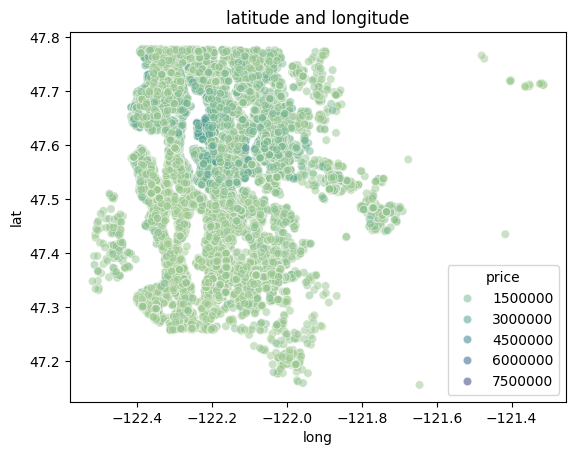

In [ ]:
#| label: fig-coord
#| fig-cap: "Scatter plot of geographic numeric features and house price"
sns.scatterplot(data=data, x='long', y='lat',  hue='price', palette="crest", alpha=0.5)
plt.title("latitude and longitude")
plt.show()

**Categorical Variable vs. Price**

As per @fig-bi-cat, 'waterfront' houses have higher median prices and wider price ranges than houses without 'waterfront', despite being a minority in the dataset. 'View' has a weak positive, but overlapping, relationship with price. 'Condition' shows little link. 'Grade' has the the clearest and most consistent positive relationship with price, with median price rising substantially from grade 7 upwards

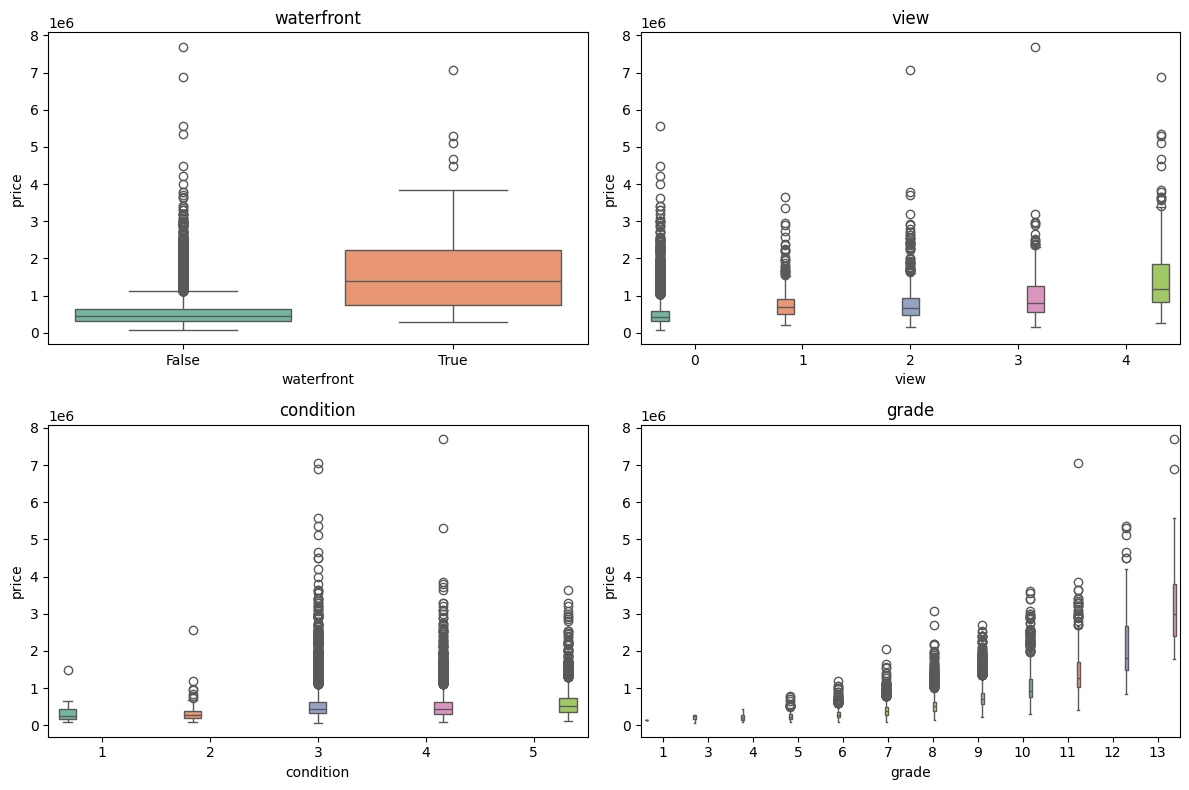

In [ ]:
#| label: fig-bi-cat
#| fig-cap: "Box plots of categorical features and house price"
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, var in enumerate(col_cat):
    sns.boxplot(data=data, x=var, y='price',
                hue=var, palette='Set2', ax=axes.flatten()[i], legend=False)
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

## Multivariate analysis {#sec-du-num-mult}

This section further examines correlations with price, interactions among features, and potential multicollinearity. Full correlation matrix is shown in @fig-mult-var-corr.

As per @tbl-mult-corr-price, 'sqft_living' has the strongest correlation with price (0.70), followed by 'sqft_above' (0.61) and 'grade' (0.67).

Several features show strong inter-correlation. 'Sqft_living' with 'sqft_above' (0.88), sqft_living15' (0.76) and bathrooms (0.75) (@tbl-mult-corr-sqft_living). 'Grade' is correlated with 'sqft_living' (0.76), 'sqft_above' (0.76), and 'bathrooms' (0.66), (@tbl-mult-corr-grade).

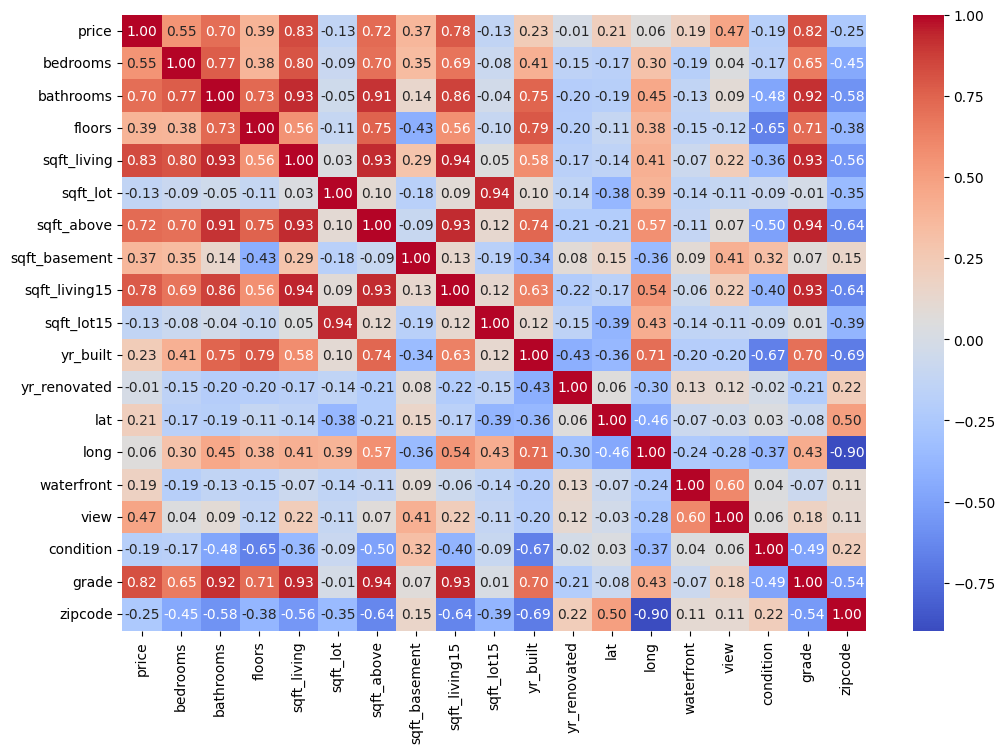

In [ ]:
#| label: fig-mult-var-corr
#| fig-cap: "Correlation matrix"

plt.figure(figsize=(12, 8))

corr = data[['price'] + col_num_counts + col_num_area + col_num_temp + col_num_geo + col_cat + ['zipcode']].corr()

sns.heatmap(corr.corr(method='pearson'),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [ ]:
#| label: tbl-mult-corr-price
#| tbl-cap: Correlation values for price
print(corr['price'].sort_values(ascending=False))

price            1.000000
sqft_living      0.702045
grade            0.667440
sqft_above       0.605580
sqft_living15    0.585386
bathrooms        0.525157
view             0.397298
sqft_basement    0.323832
bedrooms         0.308384
lat              0.306990
waterfront       0.266369
floors           0.256751
yr_renovated     0.126440
sqft_lot         0.089672
sqft_lot15       0.082438
yr_built         0.053960
condition        0.036384
long             0.021648
zipcode         -0.053221
Name: price, dtype: float64


In [ ]:
#| label: tbl-mult-corr-sqft_living
#| tbl-cap: Correlation values for sqft_living
print(corr['sqft_living'].sort_values(ascending=False))

sqft_living      1.000000
sqft_above       0.876602
grade            0.762705
sqft_living15    0.756437
bathrooms        0.754682
price            0.702045
bedrooms         0.576703
sqft_basement    0.435060
floors           0.353881
yr_built         0.317955
view             0.284618
long             0.240246
sqft_lot15       0.183279
sqft_lot         0.172838
waterfront       0.103819
yr_renovated     0.055372
lat              0.052515
condition       -0.058717
zipcode         -0.199451
Name: sqft_living, dtype: float64


In [ ]:
#| label: tbl-mult-corr-grade
#| tbl-cap: Correlation values for grade
print(corr['grade'].sort_values(ascending=False))

grade            1.000000
sqft_living      0.762705
sqft_above       0.755926
sqft_living15    0.713322
price            0.667440
bathrooms        0.664975
floors           0.458146
yr_built         0.446907
bedrooms         0.356984
view             0.251326
long             0.198385
sqft_basement    0.168406
sqft_lot15       0.119242
lat              0.114077
sqft_lot         0.113629
waterfront       0.082777
yr_renovated     0.014420
condition       -0.144655
zipcode         -0.184873
Name: grade, dtype: float64


# Pre-Processing {#sec-pp}

This section outlines the pre-processing steps previously identified. Outlier and missing value treatments, along with skewness corrections, were applied, with further recommendations provided.

## Missing data and outliers {#sec-pp-miss-out}

**Missing values**

Four records had missing values in 'sqft_living15' and 'sqft_lot15' (@tbl-pp-miss). Median imputation was applied, with negligible impact.

In [ ]:
#| label: tbl-pp-miss
#| tbl-cap: Records with missing sqft_living15 and sqft_sqft_lot15 values
cols = [0, 1, 5, 6, 19, 20]
data[data["sqft_living15"].isna() | data["sqft_lot15"].isna()].iloc[:, cols]

,id,date,sqft_living,sqft_lot,sqft_living15,sqft_lot15
18,16000397,2014-12-05,1200,9850,1060.0,NaN
29,1873100390,2015-03-02,2570,7173,NaN,6026.0
31,2426039314,2014-12-01,1190,1265,1390.0,NaN
36,9435300030,2014-05-28,1660,34848,NaN,11467.0


In [ ]:
data["sqft_living15"] = data["sqft_living15"].fillna(data["sqft_living15"].median())
data["sqft_lot15"] = data["sqft_lot15"].fillna(data["sqft_lot15"].median())

**Outlier**

The 33-bedroom record was assumed a data entry error (sqft_living 1,620 sqft) (@tbl-pp-out). Similar properties averaged 3.4 bedrooms @tbl-pp-out-check), so this was corrected to 3.

In [ ]:
#| label: tbl-pp-out
#| tbl-cap: Record with an extreme bedroom value
cols = [0, 3, 4, 5, 7, 12]
data[data["bedrooms"] == 33].iloc[:, cols]

,id,bedrooms,bathrooms,sqft_living,floors,sqft_above
15870,2402100895,33,1.75,1620,1.0,1040


In [ ]:
#| label: tbl-pp-out-check
#| tbl-cap: Records with sqft_living value of 1620
cols = [0, 3, 4, 5, 7, 12]
data[data["sqft_living"].between(1620, 1620)].iloc[:, cols]

,id,bedrooms,bathrooms,sqft_living,floors,sqft_above
20,6300500875,4,1.75,1620,1.0,860
842,9429500045,3,1.00,1620,1.5,1620
871,4039300400,3,2.25,1620,1.0,1220
1189,9558020890,3,2.50,1620,2.0,1620
1269,2919702075,3,1.75,1620,1.0,980
...,...,...,...,...,...,...
20930,9126100813,3,2.25,1620,3.0,1620
20995,9268851320,3,2.25,1620,2.5,1540
21152,9268850290,3,2.25,1620,3.0,1540
21183,5528600005,2,2.50,1620,2.0,1620


In [ ]:
data[data["sqft_living"].between(1620, 1620)]["bedrooms"].mean()

np.float64(3.3636363636363638)

In [ ]:
data.loc[data["bedrooms"] == 33, "bedrooms"] = 3

## Skewness correction {#sec-pp-skewness}

As identified in @sec-du-target, 'price' was right-skewed (@fig-raw-price). Log transformation (@fig-log-price) made the distribution more symmetrical with improved normality (@fig-log-price).

In [ ]:
data['log_price'] = np.log(data['price'])

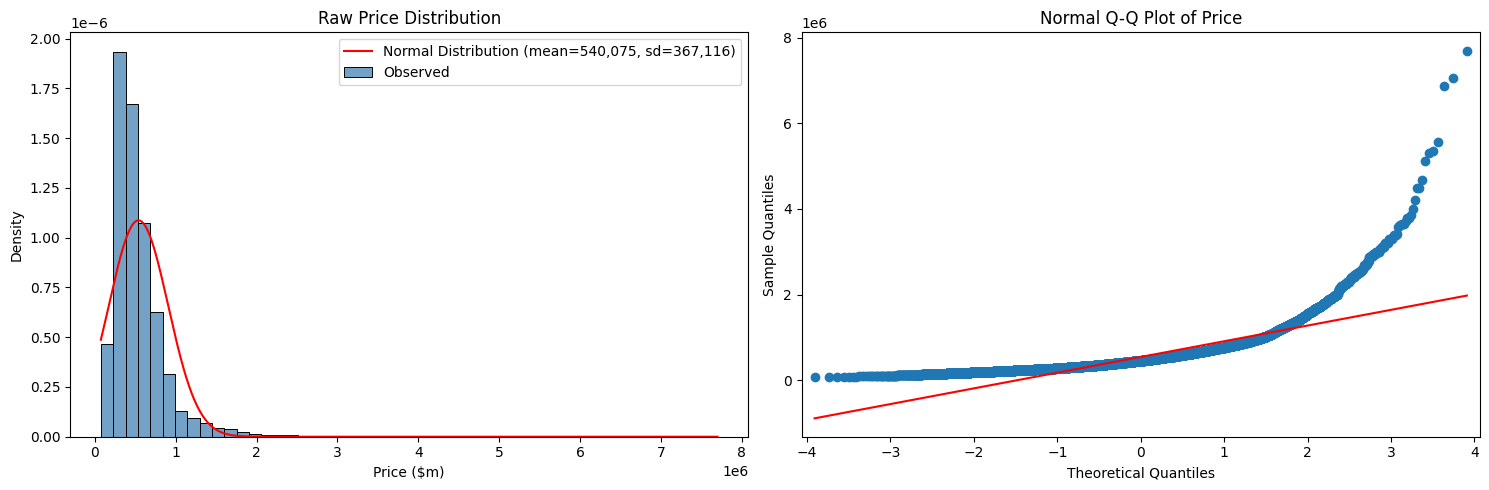

In [ ]:
#| label: fig-raw-price
#| fig-cap: "Price distribution"

price = data['price']
mu, std = stats.norm.fit(price)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# histogram
sns.histplot(price, bins=50, stat='density', color='steelblue', ax=axes[0],
             label='Observed')
axes[0].plot(price.sort_values(), stats.norm.pdf(price.sort_values(), mu, std), 
             color='red', label=f'Normal Distribution (mean={mu:,.0f}, sd={std:,.0f})')
axes[0].legend()
axes[0].set_title('Raw Price Distribution')
axes[0].set_xlabel('Price ($m)')

# Q-Q plot
sm.qqplot(price, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot of Price')

plt.tight_layout()
plt.show()

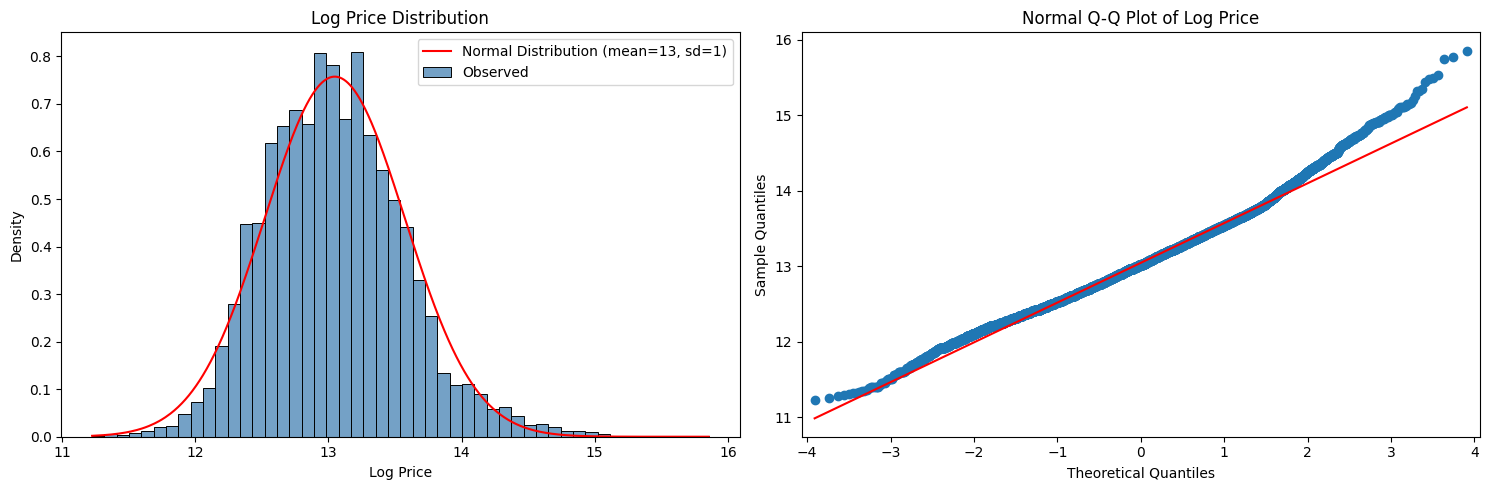

In [ ]:
#| label: fig-log-price
#| fig-cap: "Price distribution (log transformed)"

log_price = np.log(data['price'])
mu, std = stats.norm.fit(log_price)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# histogram
sns.histplot(log_price, bins=50, stat='density', color='steelblue', ax=axes[0],
             label='Observed')
axes[0].plot(log_price.sort_values(), stats.norm.pdf(log_price.sort_values(), mu, std), 
             color='red', label=f'Normal Distribution (mean={mu:,.0f}, sd={std:,.0f})')
axes[0].legend()
axes[0].set_title('Log Price Distribution')
axes[0].set_xlabel('Log Price')

# Q-Q plot
sm.qqplot(log_price, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot of Log Price')

plt.tight_layout()
plt.show()

## Exploration of pre-processed data

Key visualisations were revisited to assess the impact of the corrections and transformations applied.

Across all visualisations (@fig-bi-num-count-log, @fig-bi-num-area-log, @fig-bi-num-temp-log, @fig-bi-cat-log), the direction of previously identified relationships (@fig-bi-num-count, @fig-bi-num-area, @fig-bi-num-temp, @fig-bi-cat) is preserved following log transformation, with several patterns more clearly visible.

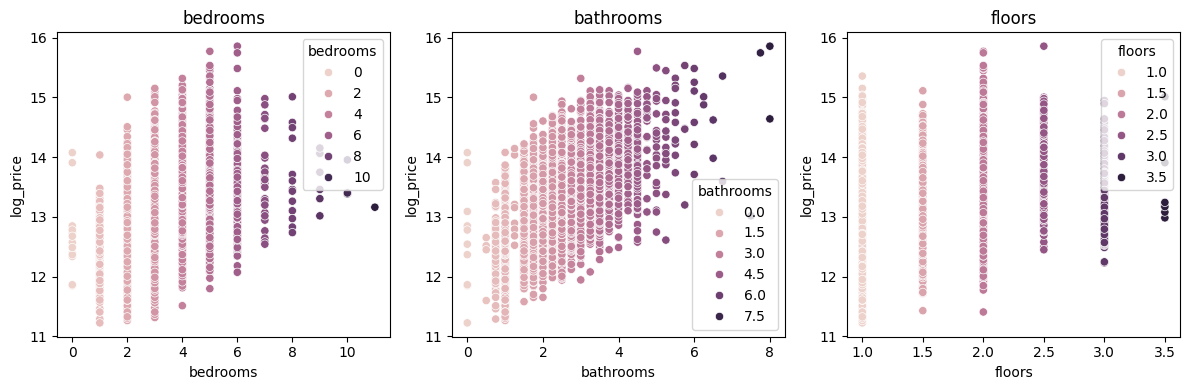

In [ ]:
#| label: fig-bi-num-count-log
#| fig-cap: "Scatter plot of discrete numeric features and house price (log)"
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, var in enumerate(col_num_counts):
    sns.scatterplot(data=data, x=var, y='log_price', hue = var, ax=axes[i])
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

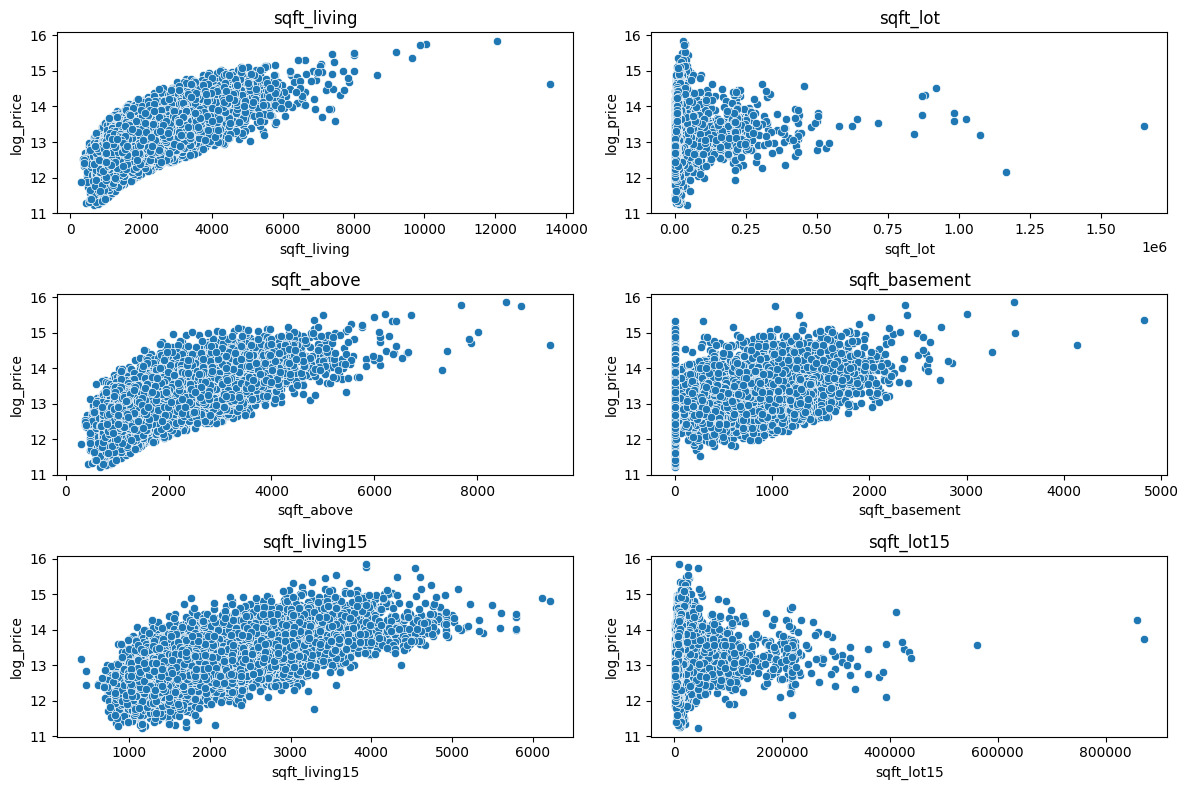

In [ ]:
#| label: fig-bi-num-area-log
#| fig-cap: "Scatter plot of area numeric features and house price (log)"
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for i, var in enumerate(col_num_area):
    sns.scatterplot(data=data, x=var, y='log_price', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

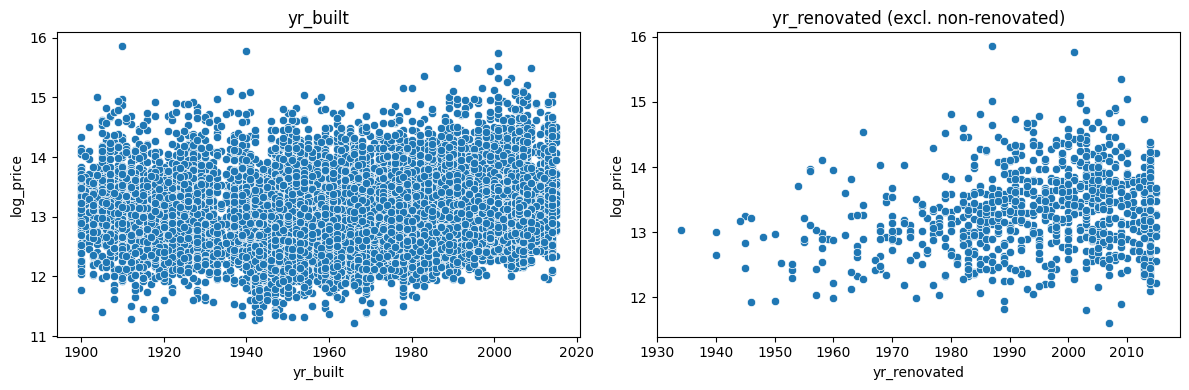

In [ ]:
#| label: fig-bi-num-temp-log
#| fig-cap: "Scatter plot of temporal numeric features and house price (log)"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(col_num_temp):
    plot_data = data[data[var] != 0] if var == "yr_renovated" else data
    sns.scatterplot(data=plot_data, x=var, y='log_price', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var if var != "yr_renovated" else "yr_renovated (excl. non-renovated)")

plt.tight_layout()
plt.show()

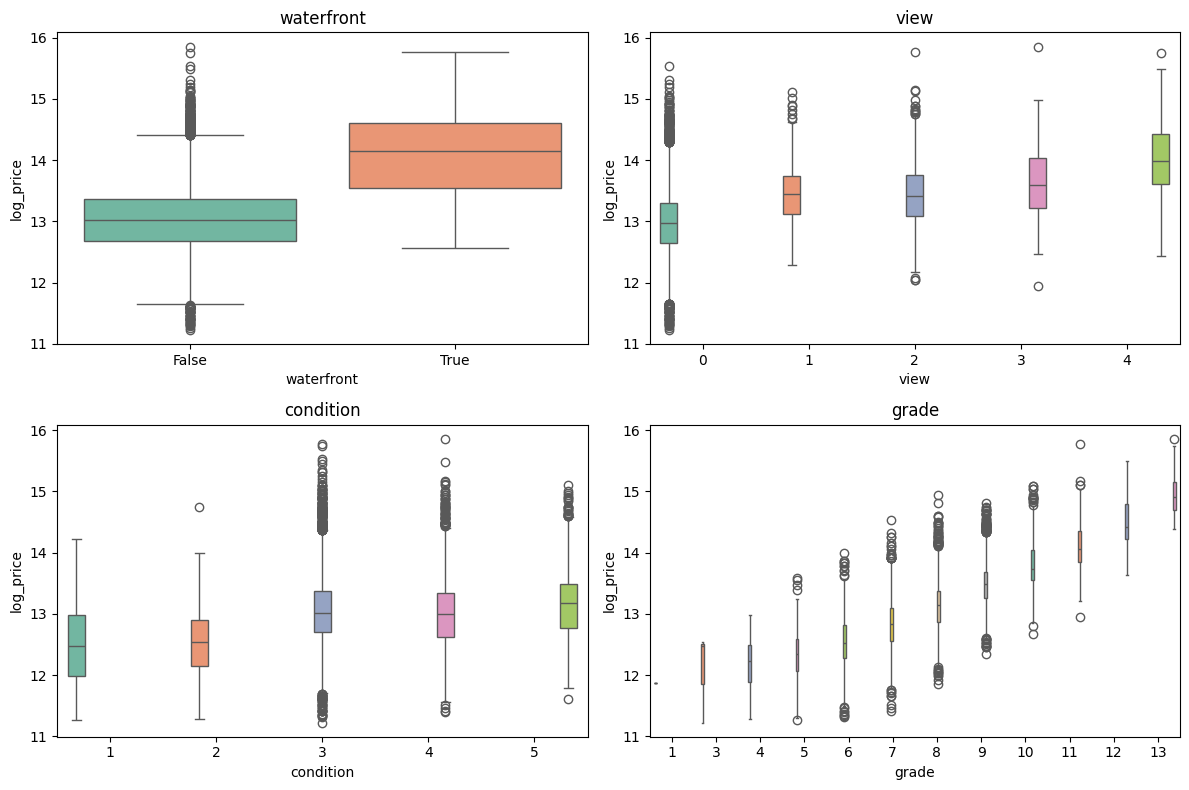

In [ ]:
#| label: fig-bi-cat-log
#| fig-cap: "Box plots of categorical features and house price (log)"
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, var in enumerate(col_cat):
    sns.boxplot(data=data, x=var, y='log_price',
                hue=var, palette='Set2', ax=axes.flatten()[i], legend=False)
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

## Further Recomendations {#sec-pp-rec}

Features could be derived from existing variables: house age and time since last renovation (calculated from date, yr_built, and yr_renovated), a binary renovation flag, and sale month or season extracted from date. Following feature engineering, 'id', 'date', 'yr_built', and 'yr_renovated' should be dropped, as they either carry no predictive value or will have been replaced by derived features. Feature selection should then be applied to address the multicollinearity identified among area variables, with further analysis used to determine which features to retain in the model. Finally, numerical features should be scaled prior to modelling — either standardised to a mean of 0 and standard deviation of 1, or normalised to a 0–1 range — to ensure all features contribute equally and no single variable dominates due to its scale. [@li2024; @simanungkalit2023].

In [ ]:
data.to_excel("mydata.xlsx")

# Conclusions

Most numerical variables were right-skewed, with a notable outlier in 'bedroom'. 'Sqft_living' and 'sqft_above' were the strongest numerical predictors of price, with grade the strongest categorical indicator, and multicollinearity evident among features. Pre-processing addressed missing values, a data entry error, and right skew in price via log transformation. Further steps — feature engineering, removal of non-predictive variables, standardisation, and feature selection to address multicollinearity — were identified but not implemented.

# Word Count

The word count for this report includes all main body text and in-text citations.

The table of contents, list of figures, list of tables, section headings and sub-headings, figures and tables with their captions, this section, the reference list, and appendices are excluded from the word count.

Word count: 1,375 (within limit of 1,250 + 10%)

# Appendix - code {#sec-appendix}

This script was written to run in sequential code chunks, as is typical in Markdown-based workflows. Each section is separated by a \# --- divider to indicate an individual executable, labelled chunk, and to organise the analysis step‑by‑step.

           id             date   price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900         3       1.00         1180   
1  6414100192  20141209T000000  538000         3       2.25         2570   
2  5631500400  20150225T000000  180000         2       1.00          770   
3  2487200875  20141209T000000  604000         4       3.00         1960   
4  1954400510  20150218T000000  510000         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     long  sqft_liv

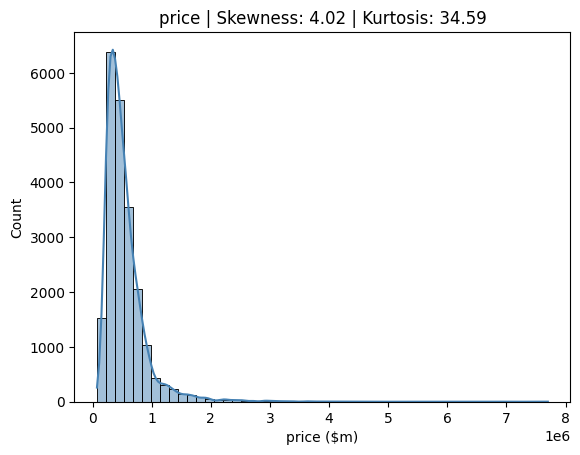

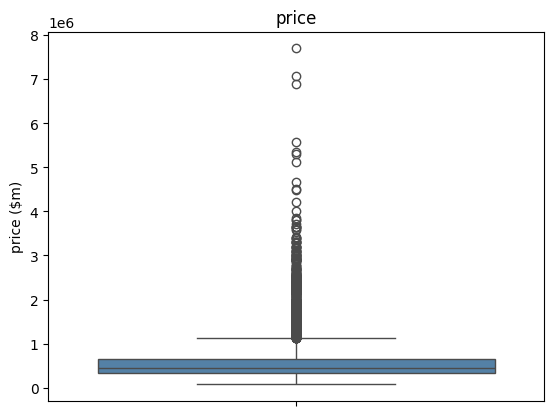

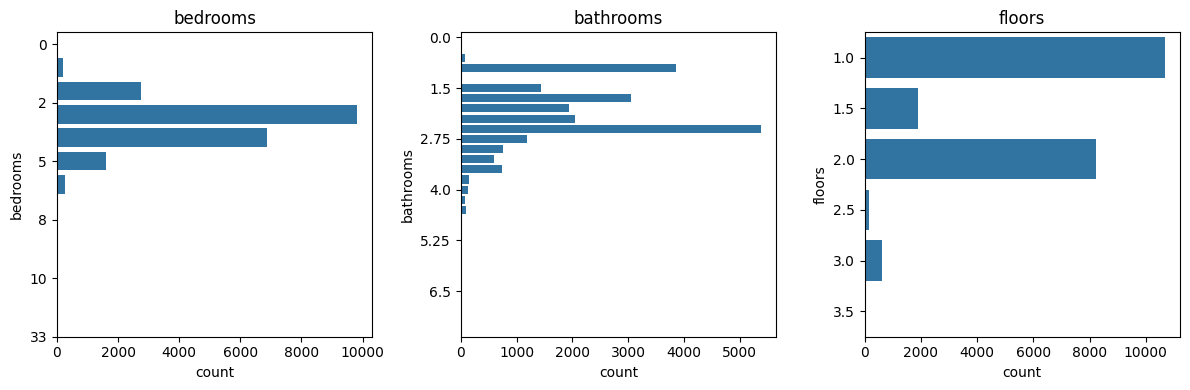

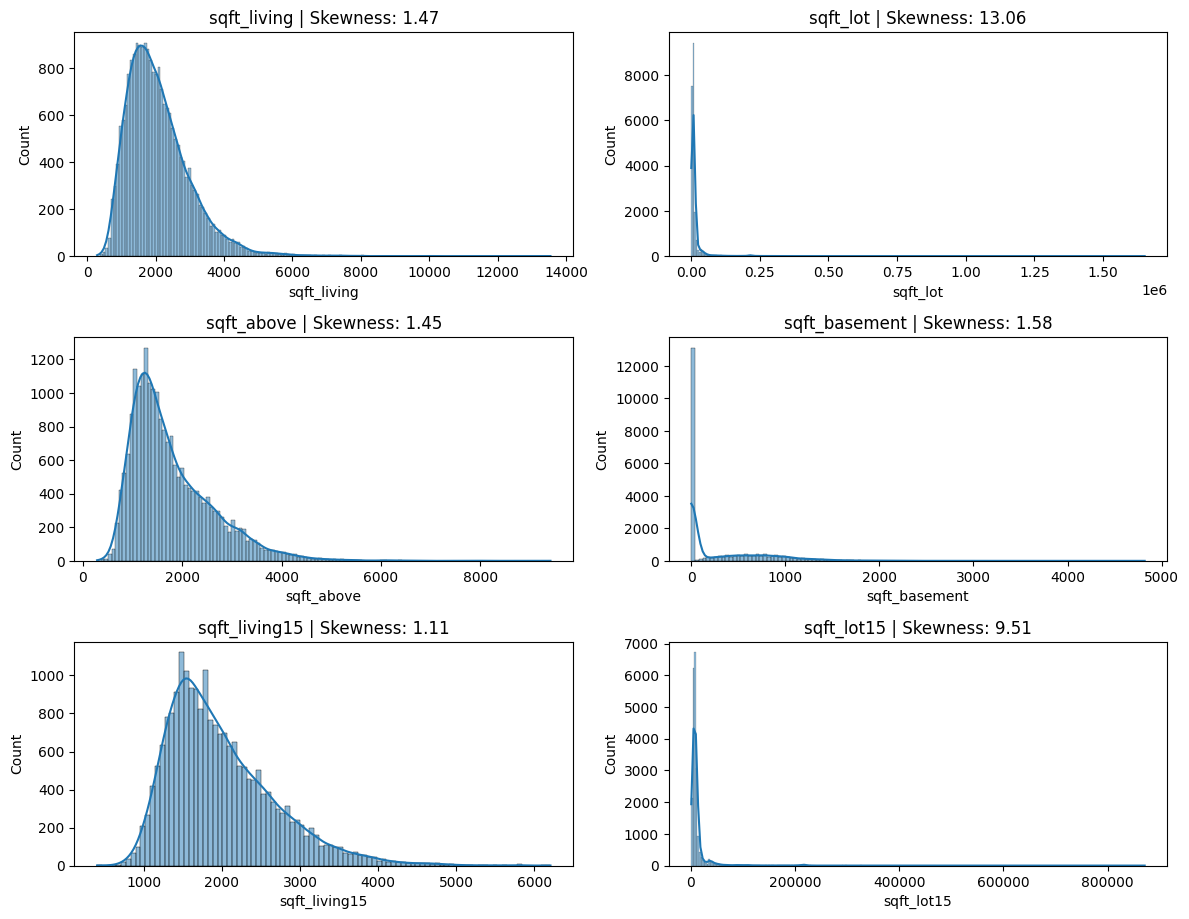

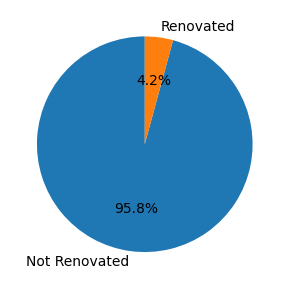

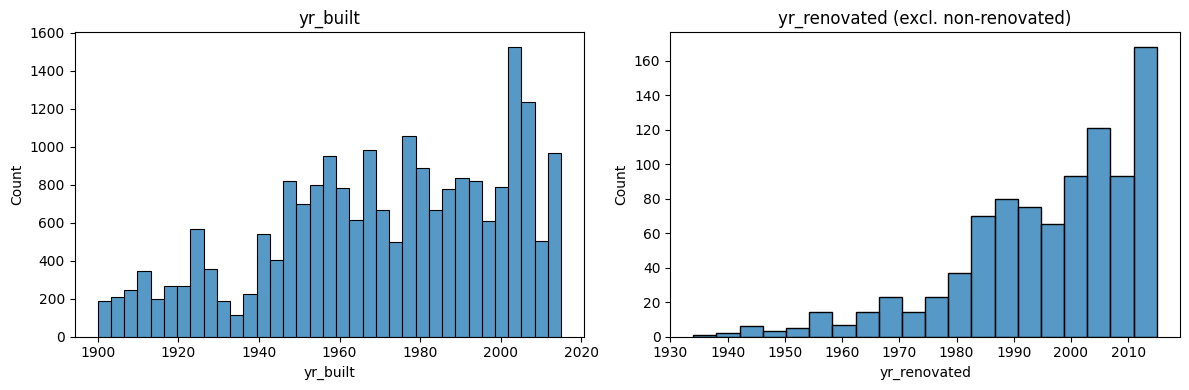

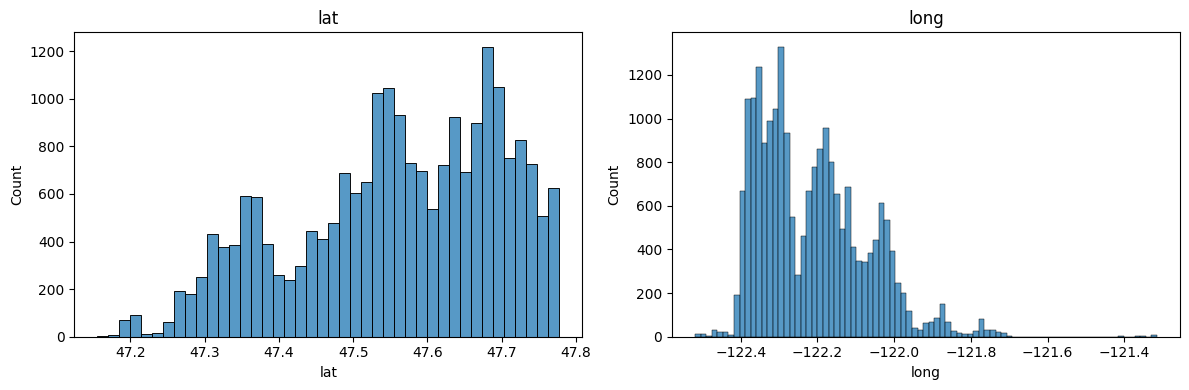

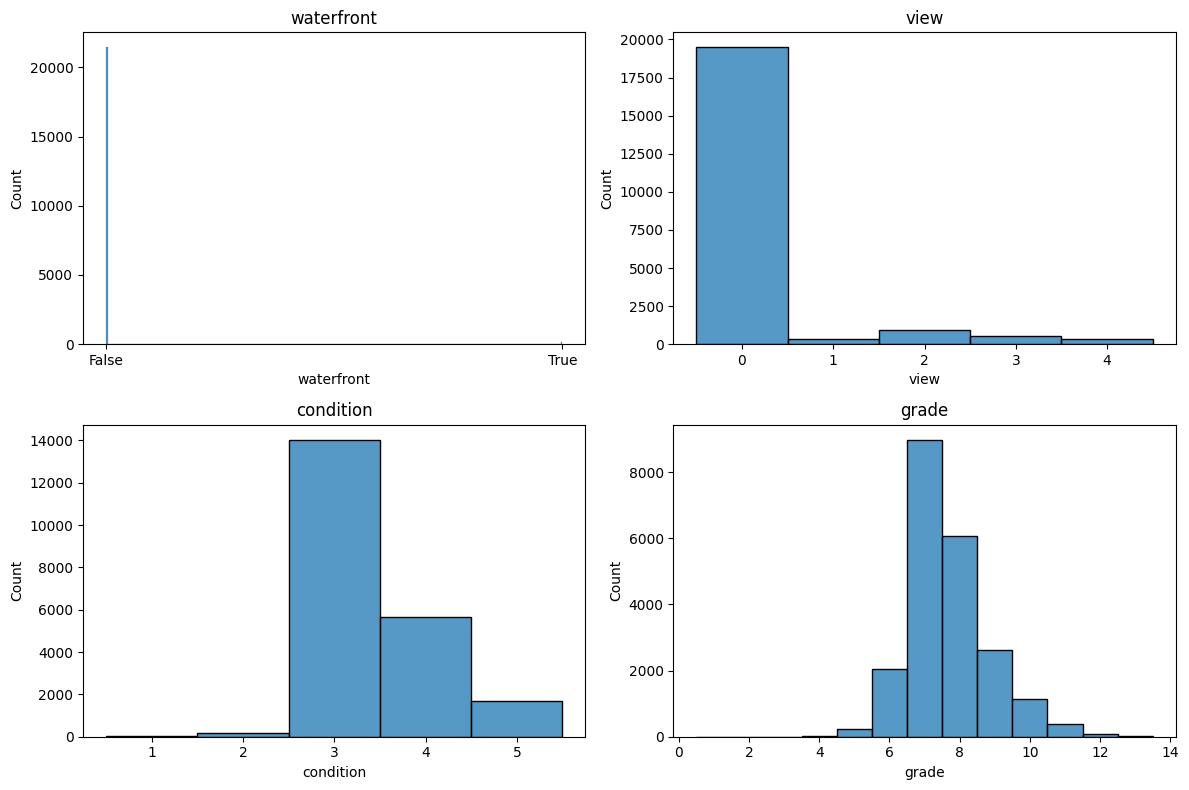

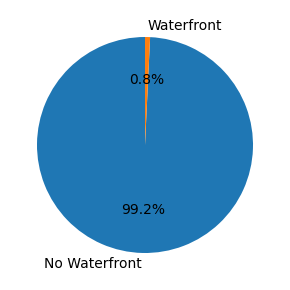

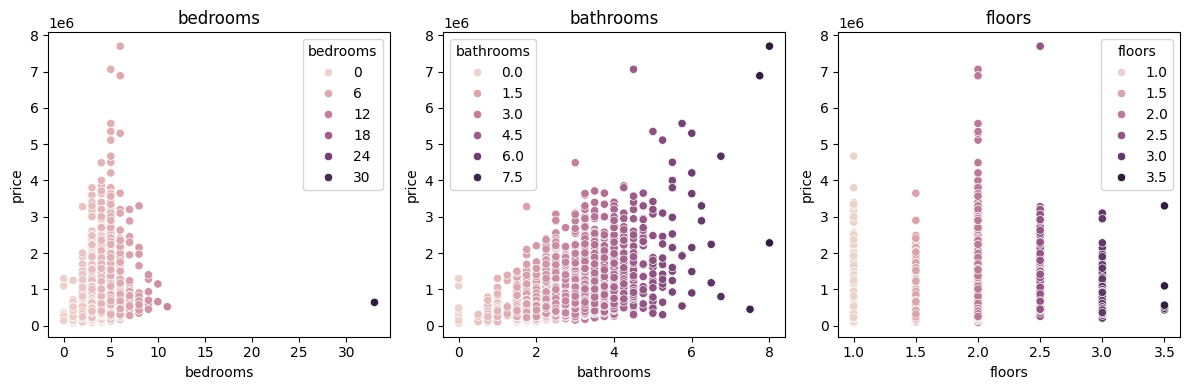

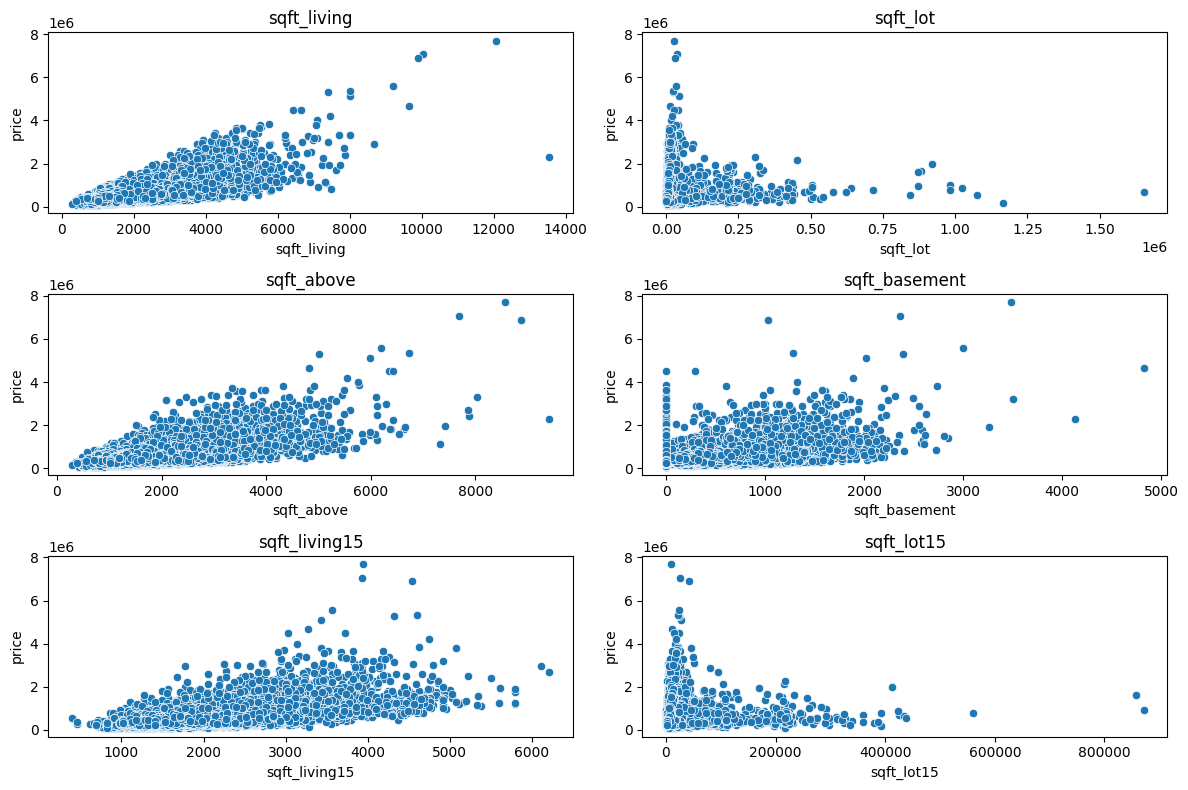

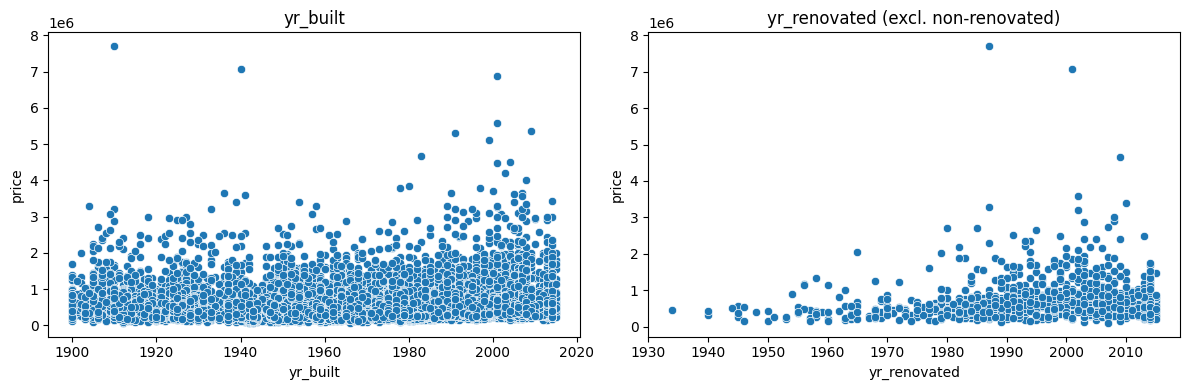

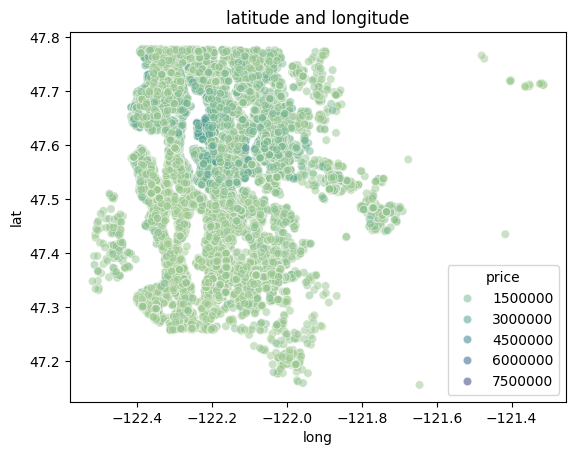

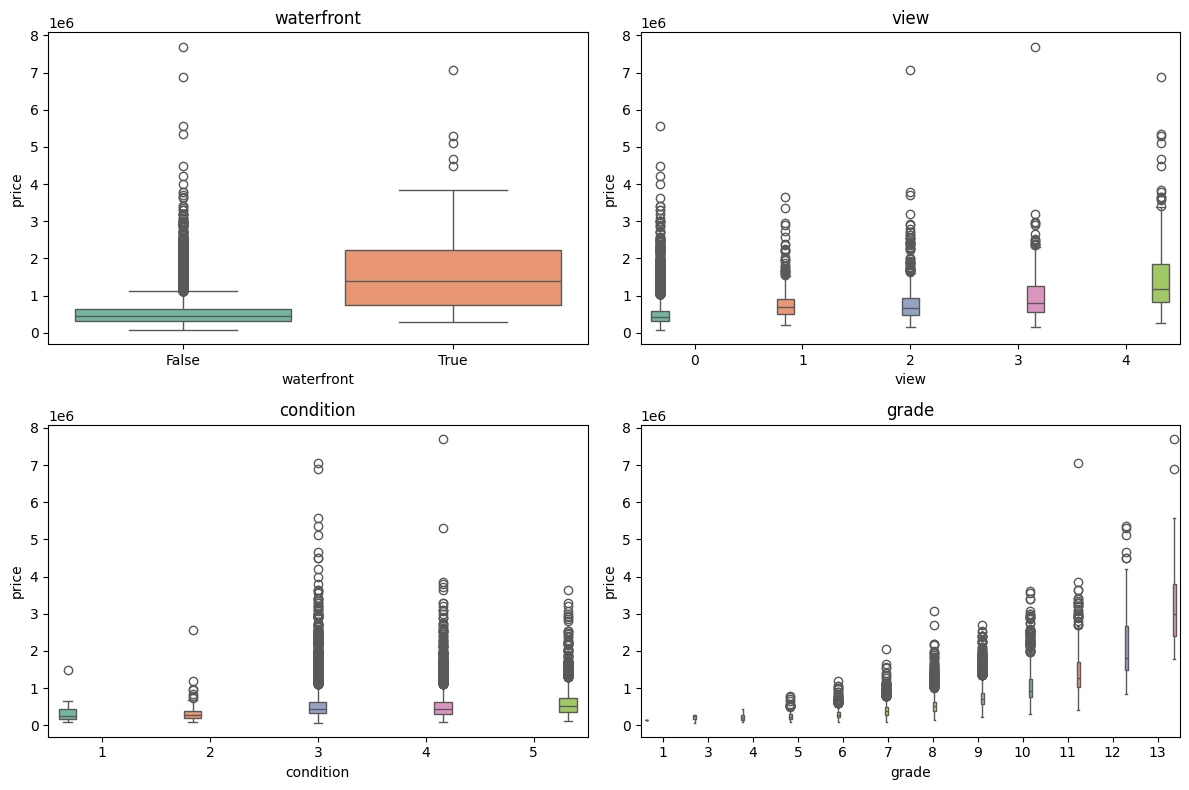

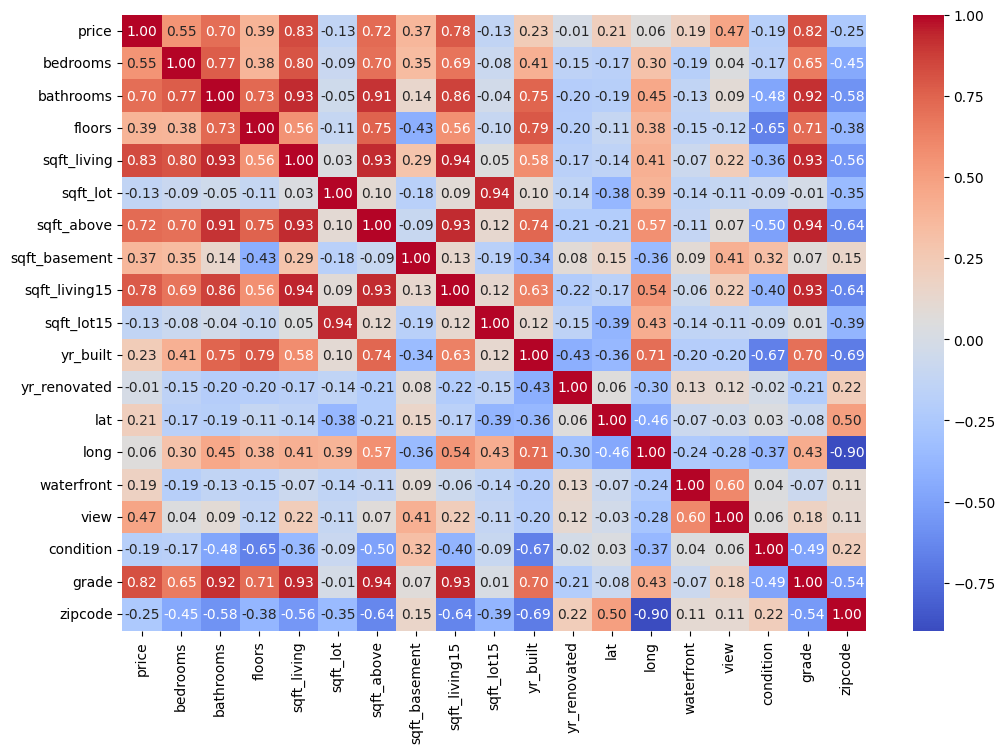

price            1.000000
sqft_living      0.702045
grade            0.667440
sqft_above       0.605580
sqft_living15    0.585386
bathrooms        0.525157
view             0.397298
sqft_basement    0.323832
bedrooms         0.308384
lat              0.306990
waterfront       0.266369
floors           0.256751
yr_renovated     0.126440
sqft_lot         0.089672
sqft_lot15       0.082438
yr_built         0.053960
condition        0.036384
long             0.021648
zipcode         -0.053221
Name: price, dtype: float64
sqft_living      1.000000
sqft_above       0.876602
grade            0.762705
sqft_living15    0.756437
bathrooms        0.754682
price            0.702045
bedrooms         0.576703
sqft_basement    0.435060
floors           0.353881
yr_built         0.317955
view             0.284618
long             0.240246
sqft_lot15       0.183279
sqft_lot         0.172838
waterfront       0.103819
yr_renovated     0.055372
lat              0.052515
condition       -0.058717
zipcode   

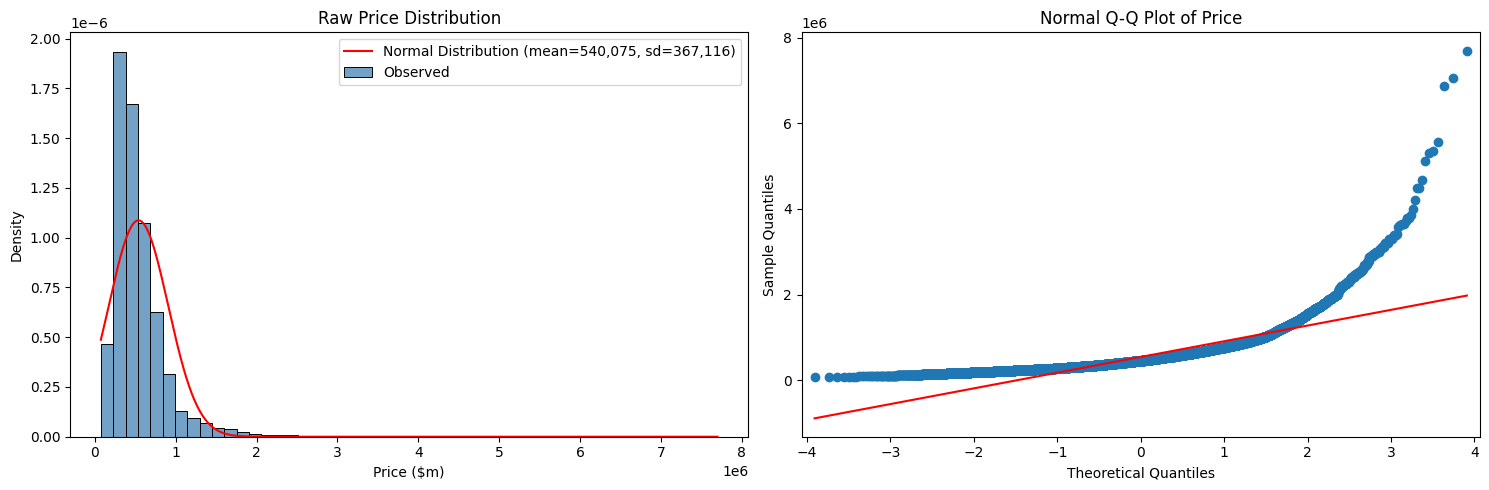

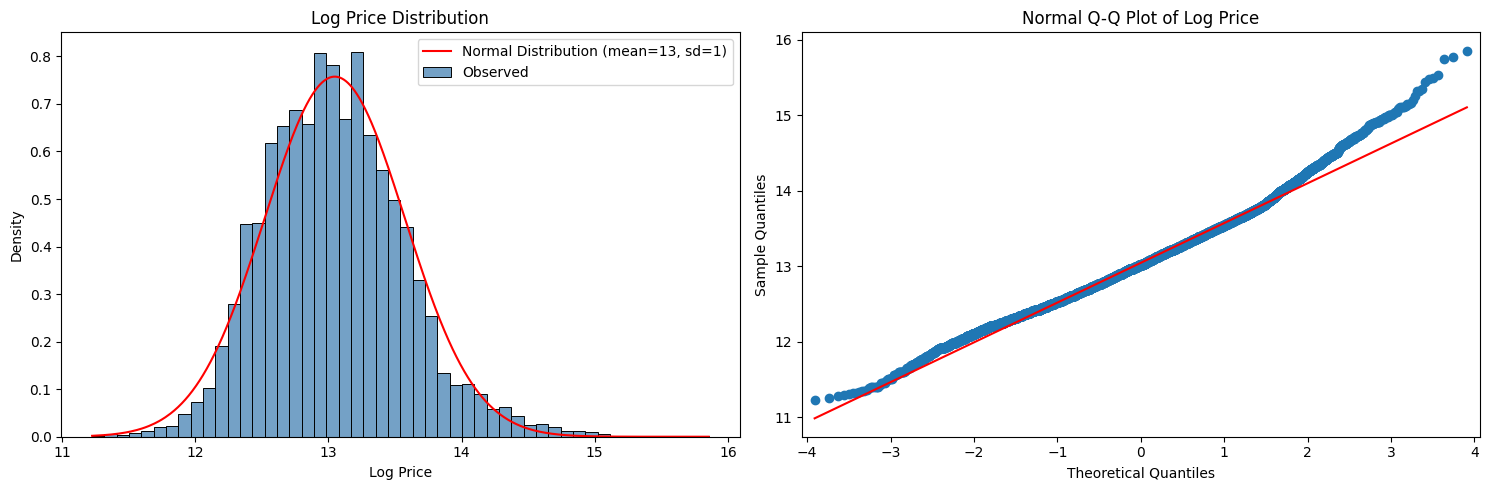

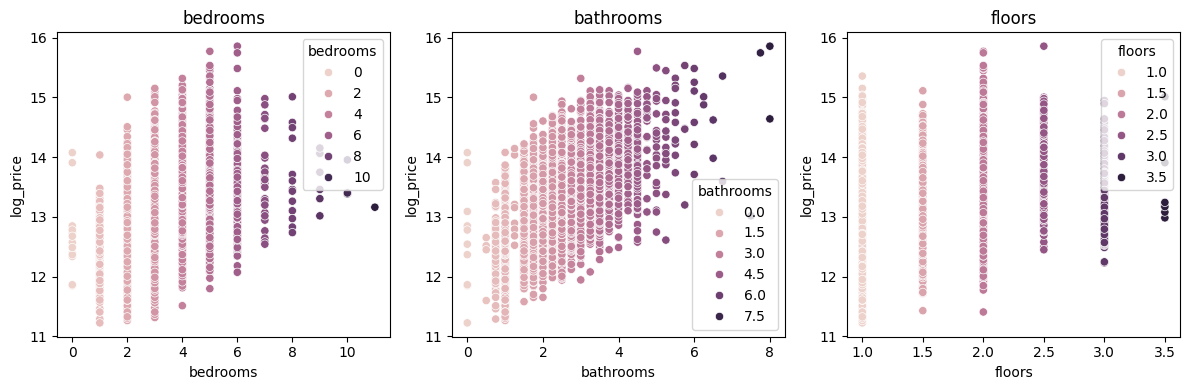

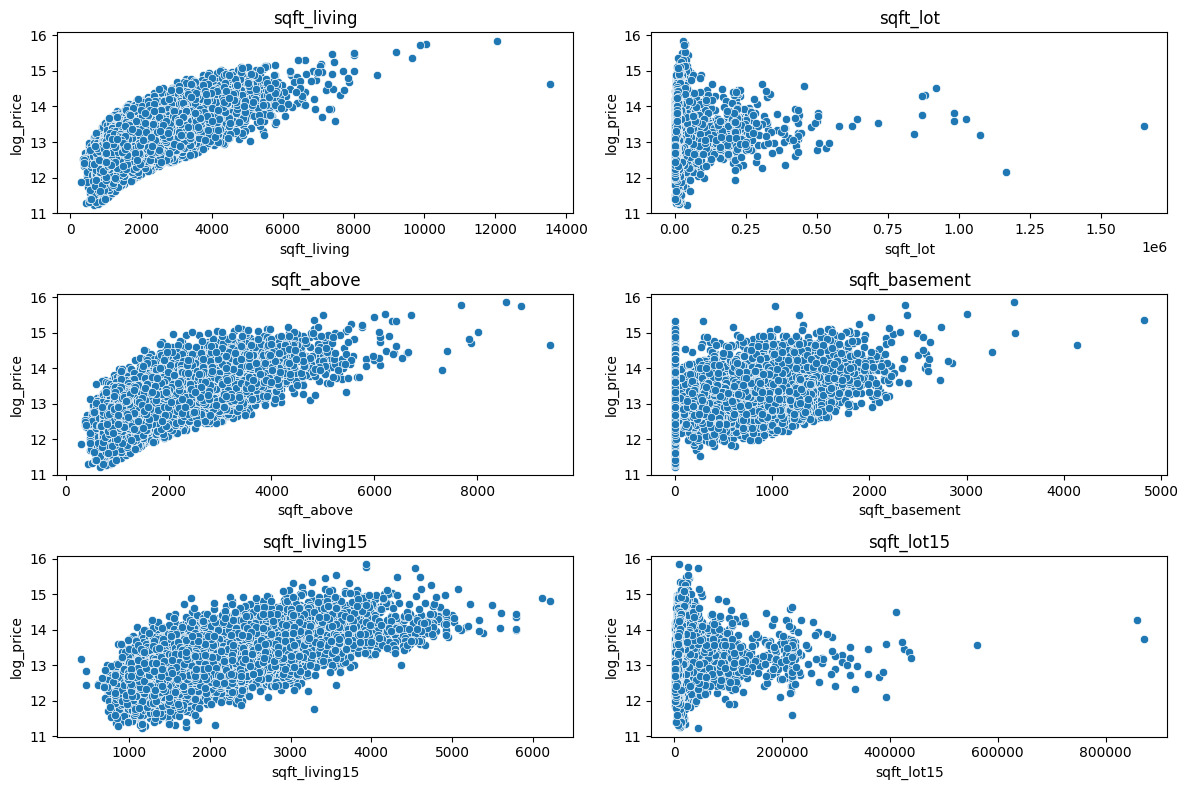

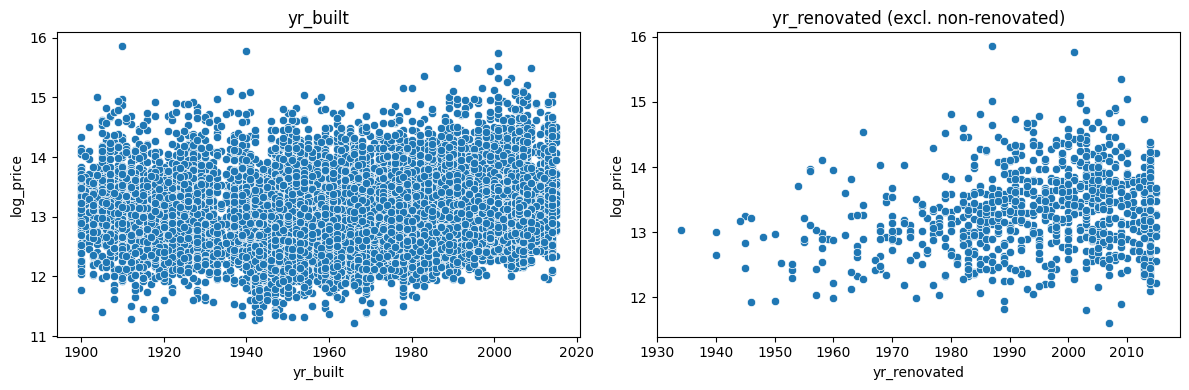

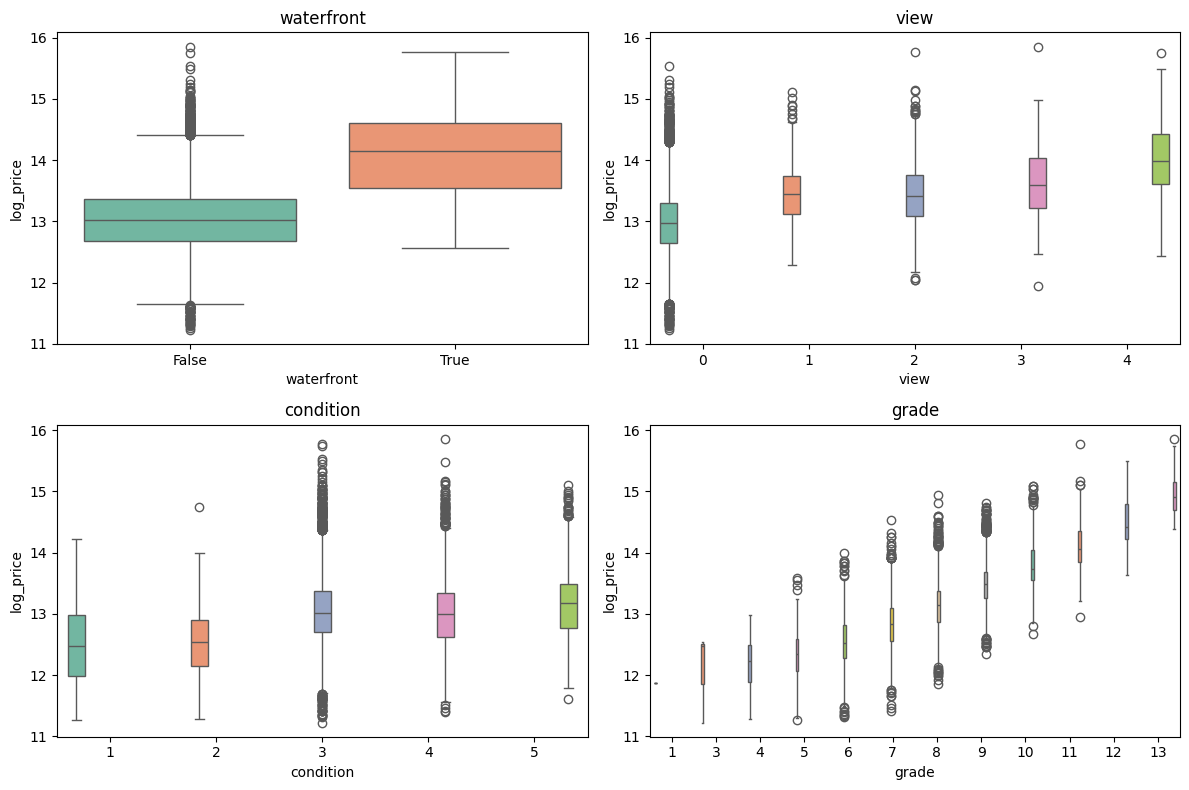

In [ ]:
#| echo: true
#| eval: false

# ----------------------------DATA UNDERSTANDING------------------------------------------ #
#| label: import-libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy.stats import norm
import statsmodels.api as sm
from tabulate import tabulate

# ---------------------------------------------------------------------------------------- # 

#| label: import-dataset
data = pd.read_csv('data/Houses_price_dataset.csv')

# ---------------------------------------------------------------------------------------- # 

#| label: data-shape
# Used for Dataset overview table
data.shape

# ---------------------------------------------------------------------------------------- # 

#| label: tbl-data-header
#| tbl-cap: "Dataset preview (first 5 rows)"
print(data.head(5))

# ---------------------------------------------------------------------------------------- # 

#| label: data-types-before
# Capture original datatypes after importing the dataset
before = data.dtypes.reset_index()
before.columns = ["Variable", "Imported dtype"]

# ---------------------------------------------------------------------------------------- # 

#| label: comments
# Make comments for the original datatypes
comments = {
    "id": "house identifierr",
    "date": "sales date",
    "price": "house sales price ",
    "bedrooms": "number of bedrooms ",
    "bathrooms": "number of bathrooms",
    "sqft_living": "square footage house",
    "sqft_lot": "square footage lot ",
    "floors": "number of floors",
    "waterfront": "includes waterfront",
    "view": "quality of the view",
    "condition": "condition of the house",
    "grade": "grade of the house",
    "sqft_above": "sqft excl. basement",
    "sqft_basement": "sqft basement",
    "yr_built": "year house built",
    "yr_renovated": "year house renovated",
    "zipcode": "zip code",
    "lat": "latitude",
    "long": "longitute",
    "sqft_living15": "sqft house, 2015",
    "sqft_lot15": "sqft lot, 2015"
}

# ---------------------------------------------------------------------------------------- # 

#| label: notes
# Make notes on validation decision
notes = {
    "id": "unord. categorical",
    "date": "datetime",
    "price": "no change ",
    "bedrooms": "no change",
    "bathrooms": "no change",
    "sqft_living": "no change",
    "sqft_lot": "no change",
    "floors": "no change",
    "waterfront": "bool (True/False)",
    "view": "ord. categorical (0–4)",
    "condition": "ord. categorical (1–5)",
    "grade": "ord. categorical (1–13)",
    "sqft_above": "no change",
    "sqft_basement": "no change",
    "yr_built": "no change",
    "yr_renovated": "no change",
    "zipcode": "unord. categorical",
    "lat": "no change",
    "long": "no change",
    "sqft_living15": "no change",
    "sqft_lot15": "no change"
}

# ---------------------------------------------------------------------------------------- # 

#| label: data-types-change
# Seven changes made to imported data types
data["id"] = data["id"].astype("category")
data["date"] = data["date"].astype("datetime64[ns]")
data["waterfront"] = data["waterfront"].astype("bool")
data["view"] = data["view"].astype("category")
data["condition"] = data["condition"].astype("category")
data["grade"] = data["grade"].astype("category")
data["zipcode"] = data["zipcode"].astype("category")

# ---------------------------------------------------------------------------------------- # 

#| label: categorical-ordered
data["view"] = data["view"].cat.as_ordered()
data["condition"] = data["condition"].cat.as_ordered()
data["grade"] = data["grade"].cat.as_ordered()

# ---------------------------------------------------------------------------------------- # 

#| label: data-types-after
# Capture validated datatypes after changes made
after = data.dtypes.reset_index()
after.columns = ["Variable", "Validated dtype"]

# ---------------------------------------------------------------------------------------- # 

#| label: tbl-data-types-before-after
#| tbl-cap: "Variables data type validation"
dtype_table = before.merge(after, on="Variable")
dtype_table["Comments"] = dtype_table["Variable"].map(comments)
dtype_table["Validation"] = dtype_table["Variable"].map(notes)
dtype_table = dtype_table[["Variable", "Imported dtype", "Validated dtype", "Comments", "Validation"]]

print(tabulate(dtype_table, headers='keys', tablefmt='latex_booktabs', showindex=False))

# ---------------------------------------------------------------------------------------- # 

#| label: tbl-data-info
#| tbl-cap: "Non-null value counts for each variable"
print(data.info())

# ---------------------------------------------------------------------------------------- #

#| label: tbl-data-unique-trans
#| tbl-cap: "Unique value counts for each variable"
data.nunique()

# ---------------------------------------------------------------------------------------- #

#| label: tbl-data-duplicate-id
#| tbl-cap: "Duplicate id records"

# Find ids that appear more than once
duplicate_ids = data[data.duplicated(subset="id", keep=False)]

# Sort by id
duplicate_ids = duplicate_ids.sort_values("id")

# Show relevant columns
cols = ["id", "date", "price", "bedrooms", "grade", "sqft_living"]
print(duplicate_ids[cols])

# Summary count
print(f"\nNumber of duplicate id records: {len(duplicate_ids)}")
print(f"Number of houses sold more than once: {duplicate_ids['id'].nunique()}")

# ---------------------------------------------------------------------------------------- #

#| label: data_subset
# Create subset for descriptive statistics
data_subset = data[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']].copy()

# ---------------------------------------------------------------------------------------- #

#| label: tbl-statistics-raw
#| tbl-cap: "Descriptive statistics"
desc_T = data_subset.describe().T.round(2)

print(tabulate(desc_T, headers='keys', tablefmt='latex_booktabs', showindex=True))

# -------------------------EXPLORATORY DATA ANALYSIS--------------------------------------- #

#| label: subset-features-num
# Create subset with numerical features - counts, area, temp, geo
col_num_counts = ['bedrooms', 'bathrooms', 'floors']
col_num_area = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']
col_num_temp = ['yr_built', 'yr_renovated']
col_num_geo = ['lat', 'long']

# ---------------------------------------------------------------------------------------- #

#| label: tbl-num-features
#| tbl-cap: "Summary of numerical features"

# Create subset with numerical features only
data_num_features = data[['bedrooms', 'bathrooms', 'floors', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'yr_built', 'yr_renovated', 'lat', 'long']].copy()
# Create table showing dtype, counts and missing
data_num_info = pd.DataFrame({
    'Variable': data_num_features.dtypes.index,
    'Non-Null Count': data_num_features.notnull().sum().values,
    'Missing': data_num_features.isnull().sum().values,
    'Dtype': data_num_features.dtypes.values
})
# print
print(data_num_info.to_markdown(index=False))

# ---------------------------------------------------------------------------------------- #

#| label: subset-features-print
print("Count variables:")
for col in col_num_counts:
    print(f"  - {col}")

print("\nArea variables:")
for col in col_num_area:
    print(f"  - {col}")

print("\nTemporal variables:")
for col in col_num_temp:
    print(f"  - {col}")

print("\nGeographical variables:")
for col in col_num_geo:
    print(f"  - {col}")

# ---------------------------------------------------------------------------------------- #

#| label: tbl-cat-features
#| tbl-cap: "Summary of categorical features"

# Create subset with numerical features only
data_cat_features = data[['waterfront', 'view', 'condition', 'grade']].copy()
# Create table showing dtype, counts and missing
data_cat_info = pd.DataFrame({
    'Variable': data_cat_features.dtypes.index,
    'Non-Null Count': data_cat_features.notnull().sum().values,
    'Missing': data_cat_features.isnull().sum().values,
    'Dtype': data_cat_features.dtypes.values
})
# print
print(data_cat_info.to_markdown(index=False))

# ---------------------------------------------------------------------------------------- #

#| label: subset-features-cat
# Specify columns for categorical features
col_cat = ['waterfront', 'view', 'condition', 'grade']

# ---------------------------------------------------------------------------------------- #

#| label: fig-target-hist
#| fig-cap: "Histogram of house price distribution"
sns.histplot(data['price'], bins=50, color='steelblue', edgecolor='black', kde=True)
plt.title(f"price | Skewness: {round(data['price'].skew(), 2)} | Kurtosis: {round(data['price'].kurt(), 2)}")
plt.xlabel('price ($m)')
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-target-box
#| fig-cap: "Box plot of house price distribution"
sns.boxplot(data['price'], color='steelblue')
plt.title("price")
plt.ylabel('price ($m)')
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-uni-num-counts
#| fig-cap: "Count plots of discrete numeric features"

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, var in enumerate(col_num_counts):
    sns.countplot(data=data, y=var, ax=axes[i])
    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=6))  # limit to 6 ticks
    axes[i].set_title(var)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-uni-num-area
#| fig-cap: "Histogram of area numeric features"

plt.figure(figsize=(12, len(col_num_area) * 3))
for i, var in enumerate(col_num_area, 1):
    plt.subplot(len(col_num_area), 2, i)
    sns.histplot(data[var], kde=True)
    plt.title(f"{var} | Skewness: {round(data[var].skew(), 2)}")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-uni-num-temp-pie
#| fig-cap: "Pie chart of renovated vs. non-renovated houses"
renovated_counts = data["yr_renovated"].apply(lambda x: "Renovated" if x != 0 else "Not Renovated").value_counts()

fig, ax = plt.subplots(figsize=(3, 3))
ax.pie(renovated_counts, labels=renovated_counts.index, autopct="%1.1f%%", startangle=90)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-uni-num-temp-hist
#| fig-cap: "Histogram of temporal numeric features"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(col_num_temp):
    plot_data = data[data[var] != 0][var] if var == "yr_renovated" else data[var]
    sns.histplot(plot_data, ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var if var != "yr_renovated" else "yr_renovated (excl. non-renovated)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-uni-num-geo
#| fig-cap: "Histogram of geographic numeric features"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(col_num_geo):
    sns.histplot(data[var], ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-uni-cat-hist
#| fig-cap: "Histograms of categorical features"
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, var in enumerate(col_cat):
    sns.histplot(data[var], ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var)
    if data[var].dtype == bool:
        axes.flatten()[i].set_xticks([0, 1])
        axes.flatten()[i].set_xticklabels(["False", "True"])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-uni-cat-pie
#| fig-cap: "Pie chart of waterfront vs. no waterfront houses"

waterfront_counts = data["waterfront"].apply(lambda x: "Waterfront" if x != 0 else "No Waterfront").value_counts()

fig, ax = plt.subplots(figsize=(3, 3))
ax.pie(waterfront_counts, labels=waterfront_counts.index, autopct="%1.1f%%", startangle=90)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-bi-num-count
#| fig-cap: "Scatter plot of discrete numeric features and house price"
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, var in enumerate(col_num_counts):
    sns.scatterplot(data=data, x=var, y='price', hue = var, ax=axes[i])
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-bi-num-area
#| fig-cap: "Scatter plot of area numeric features and house price"
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for i, var in enumerate(col_num_area):
    sns.scatterplot(data=data, x=var, y='price', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-bi-num-temp
#| fig-cap: "Scatter plot of temporal numeric features and house price"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(col_num_temp):
    plot_data = data[data[var] != 0] if var == "yr_renovated" else data
    sns.scatterplot(data=plot_data, x=var, y='price', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var if var != "yr_renovated" else "yr_renovated (excl. non-renovated)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-coord
#| fig-cap: "Scatter plot of geographic numeric features and house price"
sns.scatterplot(data=data, x='long', y='lat',  hue='price', palette="crest", alpha=0.5)
plt.title("latitude and longitude")
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-bi-cat
#| fig-cap: "Box plots of categorical features and house price"
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, var in enumerate(col_cat):
    sns.boxplot(data=data, x=var, y='price',
                hue=var, palette='Set2', ax=axes.flatten()[i], legend=False)
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-mult-var-corr
#| fig-cap: "Correlation matrix"

plt.figure(figsize=(12, 8))

corr = data[['price'] + col_num_counts + col_num_area + col_num_temp + col_num_geo + col_cat + ['zipcode']].corr()

sns.heatmap(corr.corr(method='pearson'),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: tbl-mult-corr-price
#| tbl-cap: "Correlation values for price"
#| tbl-pos: H
print(corr['price'].sort_values(ascending=False))

# ---------------------------------------------------------------------------------------- #

#| label: tbl-mult-corr-sqft_living
#| tbl-cap: "Correlation values for sqft_living"
#| tbl-pos: H
print(corr['sqft_living'].sort_values(ascending=False))

# ---------------------------------------------------------------------------------------- #

#| label: tbl-mult-corr-grade
#| tbl-cap: "Correlation values for grade"
#| tbl-pos: H
print(corr['grade'].sort_values(ascending=False))

# ------------------------------PRE-PROCESSING-------------------------------------------- #

#| label: tbl-pp-miss
#| tbl-cap: "Records with missing sqft_living15 and sqft_sqft_lot15 values"
#| tbl-pos: H
cols = [0, 1, 5, 6, 19, 20]
data[data["sqft_living15"].isna() | data["sqft_lot15"].isna()].iloc[:, cols]

# ---------------------------------------------------------------------------------------- #

# input median values
data["sqft_living15"] = data["sqft_living15"].fillna(data["sqft_living15"].median())
data["sqft_lot15"] = data["sqft_lot15"].fillna(data["sqft_lot15"].median())

# ---------------------------------------------------------------------------------------- #

#| label: tbl-pp-out
#| tbl-cap: "Record with an extreme bedroom value"
cols = [0, 3, 4, 5, 7, 12]
data[data["bedrooms"] == 33].iloc[:, cols]

# ---------------------------------------------------------------------------------------- #

#| label: tbl-pp-out-check
#| tbl-cap: "Records with sqft_living value of 1620"
cols = [0, 3, 4, 5, 7, 12]
data[data["sqft_living"].between(1620, 1620)].iloc[:, cols]

# ---------------------------------------------------------------------------------------- #

# calculate mean bedroom value properties of same size
data[data["sqft_living"].between(1620, 1620)]["bedrooms"].mean()

# ---------------------------------------------------------------------------------------- #

# correct data entry error
data.loc[data["bedrooms"] == 33, "bedrooms"] = 3

# ---------------------------------------------------------------------------------------- #

# create new variable
data['log_price'] = np.log(data['price'])

# ---------------------------------------------------------------------------------------- #

#| label: fig-raw-price
#| fig-cap: "Price distribution"

price = data['price']
mu, std = stats.norm.fit(price)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# histogram
sns.histplot(price, bins=50, stat='density', color='steelblue', ax=axes[0],
             label='Observed')
axes[0].plot(price.sort_values(), stats.norm.pdf(price.sort_values(), mu, std), 
             color='red', label=f'Normal Distribution (mean={mu:,.0f}, sd={std:,.0f})')
axes[0].legend()
axes[0].set_title('Raw Price Distribution')
axes[0].set_xlabel('Price ($m)')

# Q-Q plot
sm.qqplot(price, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot of Price')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-log-price
#| fig-cap: "Price distribution (log transformed)"

log_price = np.log(data['price'])
mu, std = stats.norm.fit(log_price)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# histogram
sns.histplot(log_price, bins=50, stat='density', color='steelblue', ax=axes[0],
             label='Observed')
axes[0].plot(log_price.sort_values(), stats.norm.pdf(log_price.sort_values(), mu, std), 
             color='red', label=f'Normal Distribution (mean={mu:,.0f}, sd={std:,.0f})')
axes[0].legend()
axes[0].set_title('Log Price Distribution')
axes[0].set_xlabel('Log Price')

# Q-Q plot
sm.qqplot(log_price, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot of Log Price')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-bi-num-count-log
#| fig-cap: "Scatter plot of discrete numeric features and house price (log)"
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, var in enumerate(col_num_counts):
    sns.scatterplot(data=data, x=var, y='log_price', hue = var, ax=axes[i])
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-bi-num-area-log
#| fig-cap: "Scatter plot of area numeric features and house price (log)"
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for i, var in enumerate(col_num_area):
    sns.scatterplot(data=data, x=var, y='log_price', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-bi-num-temp-log
#| fig-cap: "Scatter plot of temporal numeric features and house price (log)"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(col_num_temp):
    plot_data = data[data[var] != 0] if var == "yr_renovated" else data
    sns.scatterplot(data=plot_data, x=var, y='log_price', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(var if var != "yr_renovated" else "yr_renovated (excl. non-renovated)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------- #

#| label: fig-bi-cat-log
#| fig-cap: "Box plots of categorical features and house price (log)"
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, var in enumerate(col_cat):
    sns.boxplot(data=data, x=var, y='log_price',
                hue=var, palette='Set2', ax=axes.flatten()[i], legend=False)
    axes.flatten()[i].set_title(var)

plt.tight_layout()
plt.show()

# References